# 

# Clean Energy Market Segmentation and CO₂ Emissions Analysis with Forecasting and Regression


## Business Understanding

### Project Overview

Climate change is a major global challenge driven largely by greenhouse gas emissions, particularly carbon dioxide (CO₂). However, emission patterns differ significantly across countries due to differences in population, economic activity, energy consumption, and dependence on fossil fuels.

Understanding both the *current emission characteristics of countries* and *how emissions are likely to change over time* can support governments, environmental organizations, and policymakers in developing more targeted climate strategies.

This project uses historical country-level CO₂ emissions data to examine emission patterns through two complementary machine learning approaches: *classification and time-series forecasting*.

### Business Problem

Countries have different levels and patterns of CO₂ emissions, making it difficult to apply the same environmental strategies across all regions. In addition, historical emission trends alone do not provide sufficient information about how emissions may develop in the future.

Therefore, there is a need to:

1. Identify and classify countries according to meaningful CO₂ emission characteristics using demographic, economic, energy, and emission-related factors.
2. Analyze historical CO₂ emission patterns over time and forecast future emission trends.

Combining classification and time-series forecasting provides both a *comparative view of emission profiles* and a *forward-looking view of how emissions may change over time*.

### Project Objectives

The main objective of this project is to use historical CO₂ emissions data to understand emission patterns across countries and predict future emission trends.

The specific objectives are:

- Explore historical CO₂ emission patterns across countries and over time.
- Identify economic, demographic, energy, and emission-related factors associated with differences in CO₂ emissions.
- Develop a *classification model* to categorize country observations according to defined CO₂ emission levels or profiles.
- Develop a *time-series forecasting model* to predict future CO₂ emissions using historical emission patterns.
- Compare model performance using appropriate classification and forecasting evaluation metrics.
- Generate insights that can support environmental planning and climate-related decision-making.

### Modeling Approach

The project will use two modeling approaches:

*1. Classification*

Classification models will be used to categorize observations into defined CO₂ emission classes. Relevant economic, demographic, energy, and emission-related variables will be evaluated as potential predictors.

Classification performance will be evaluated using metrics such as *accuracy, precision, recall, F1-score, and the confusion matrix*.

*2. Time-Series Forecasting*

Time-series models will be used to analyze historical CO₂ emission trends and forecast future emissions. Since the dataset contains annual observations from *1950 to 2024*, the temporal ordering of observations will be preserved during model development and evaluation.

Forecasting performance will be evaluated using appropriate error metrics such as *Mean Absolute Error (MAE)* and *Root Mean Squared Error (RMSE)*.

### Expected Outcome

The project is expected to produce:

- A clearer understanding of how CO₂ emissions differ across countries.
- Identification of important factors associated with emission levels.
- A classification model capable of distinguishing defined emission categories.
- A time-series model capable of forecasting future CO₂ emission trends.
- Actionable insights into historical and potential future emission patterns that can support climate planning and policy decisions.

## Data Understanding

## Data Source

The project will primarily use the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions dataset**.

The dataset provides historical country-level information on:

- CO₂ emissions
- CO₂ emissions growth
- CO₂ per capita
- Carbon intensity of GDP
- Population
- GDP
- Primary energy consumption
- Energy consumption per capita
- Energy intensity
- Coal emissions
- Oil emissions
- Gas emissions
- Cement emissions
- Flaring emissions
- Land-use change emissions


In [43]:
# Importing the neccesary libraries
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Loading the dataset
df = pd.read_csv('owid-co2-data.csv')
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Checking the shape
df.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [46]:
# Checking the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It looks like there are missing data in the dataset.

In [47]:
# Checking for missing data
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percent': df.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

In cleaning of this dataset, we have to be careful in how we will clean it because of its large number of missing values.

In [48]:
# Checking the column names
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [49]:
# Checking the decsription of the dataset
describe = df.describe()
describe

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

The descriptive statistics show substantial variation and skewness across the emissions dataset. CO₂ emissions have a mean of 420.23 compared with a median of 5.08, indicating strong right-skewness caused by countries with exceptionally high emissions. Population and GDP also show large differences between their median and maximum values. Several variables contain substantial missing data, with some having fewer than 5,000 available observations. These findings justify further data cleaning, missing-value treatment, and potentially log transformation of highly skewed variables before statistical modelling.

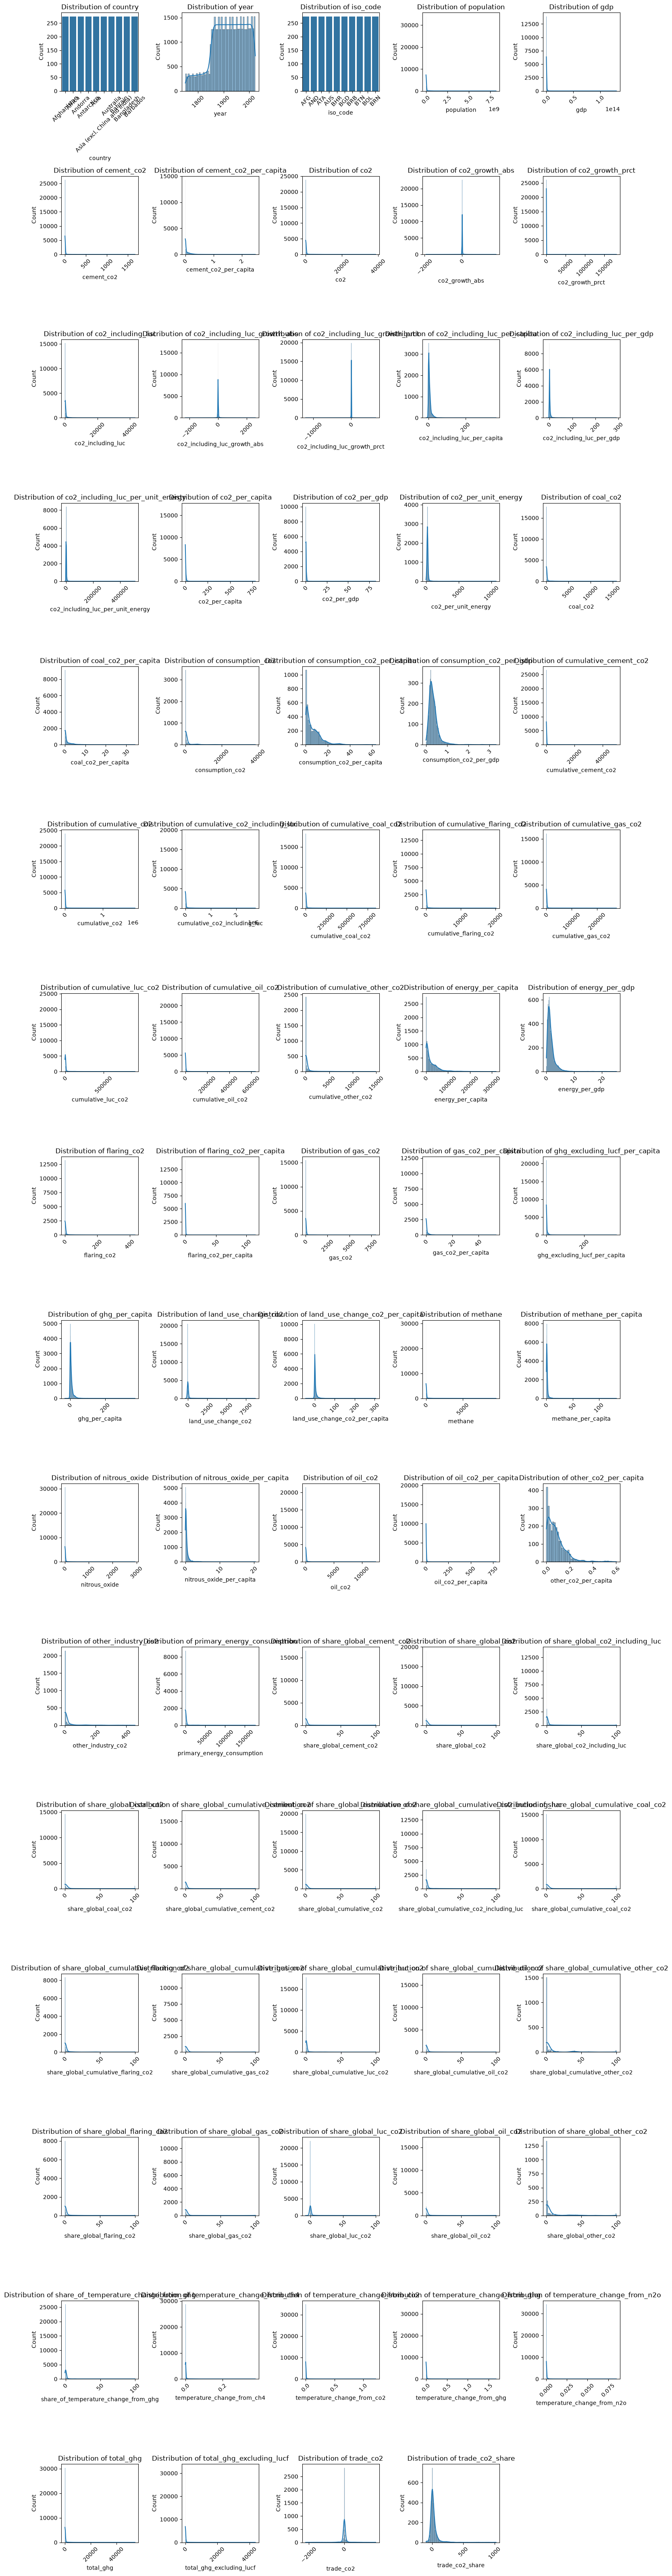

In [50]:
# Plotting the distribution of the column of the df dataset
num_cols = len(df.columns)
n_cols_per_row = 5
n_rows = (num_cols+n_cols_per_row - 1) // n_cols_per_row

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols_per_row, i+1)

    # Plotting numerical variables
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
# Plotting categorical variables
    else:
        top_cats = df[col].value_counts().iloc[:10]
        sns.barplot(x=top_cats.index, y=top_cats.values)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The numerical variables are generally right-skewed because emissions, population, GDP, and energy consumption vary greatly between countries. Therefore, the median willbe used for numerical missing-value imputation because it is less affected by extreme values than the mean. The iso_code variable was not imputed because it is categorical and its missing values can help identify regional or aggregate entities.

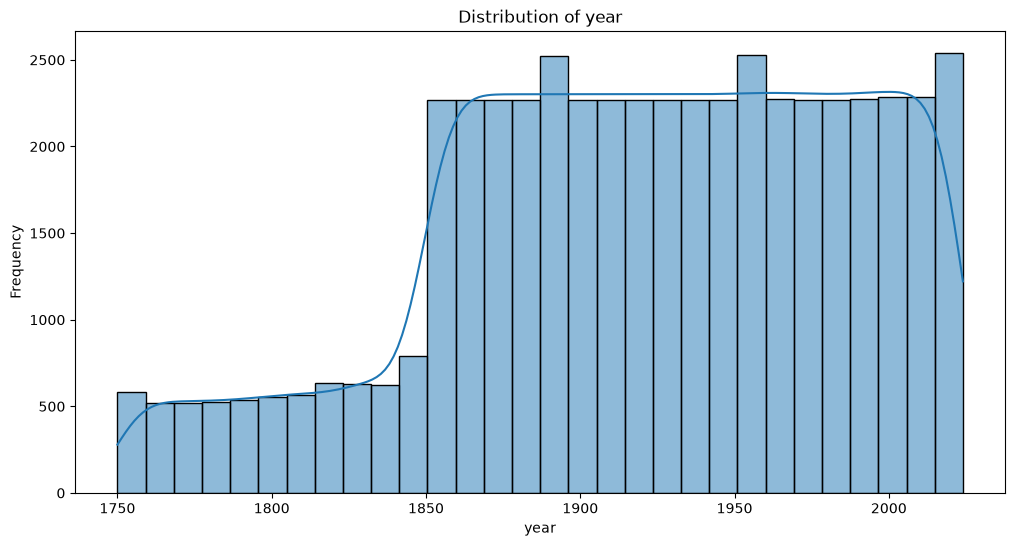

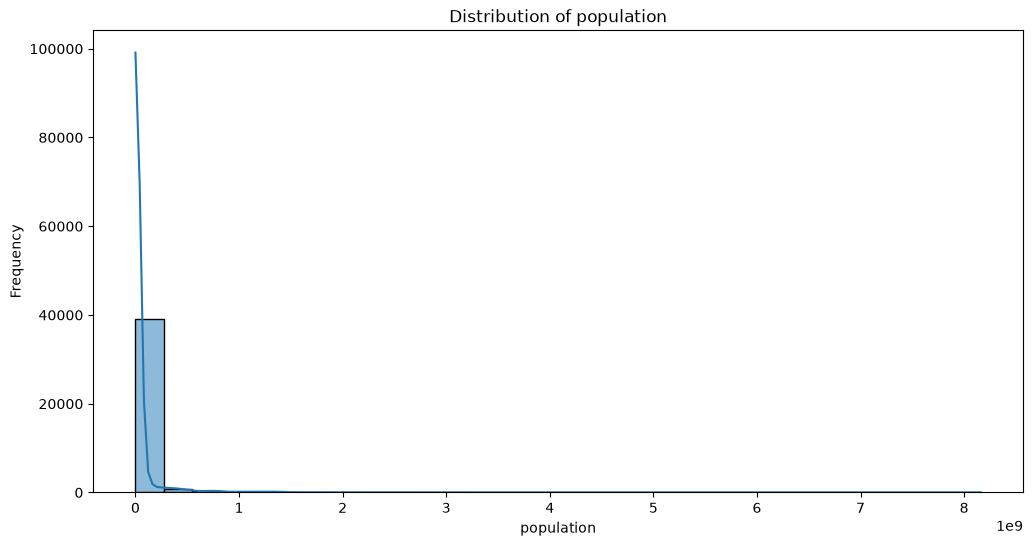

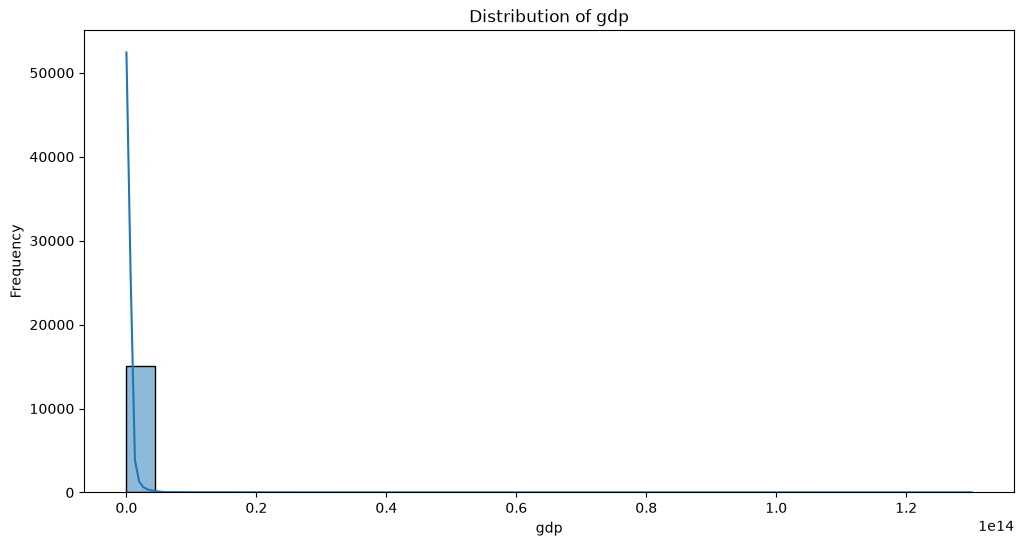

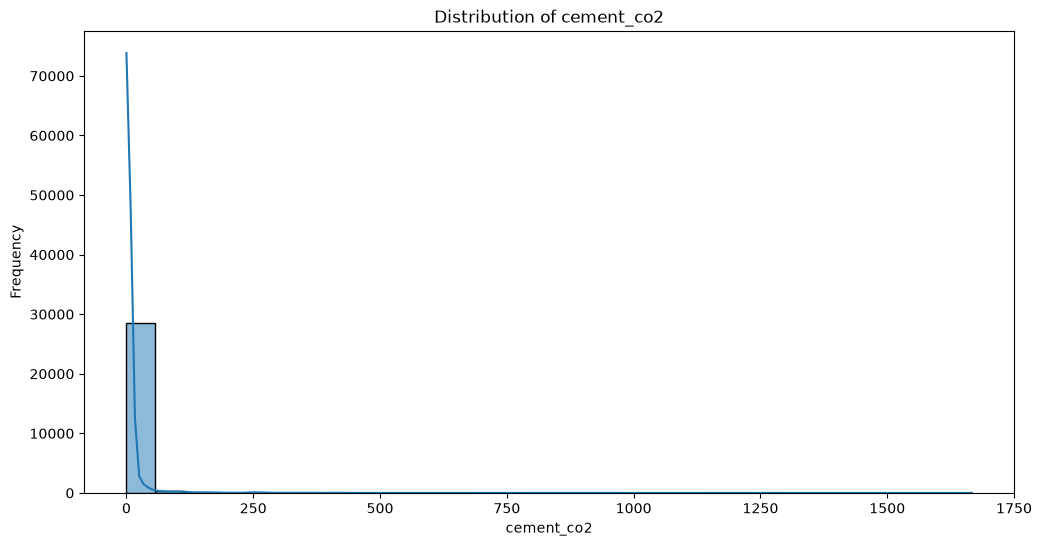

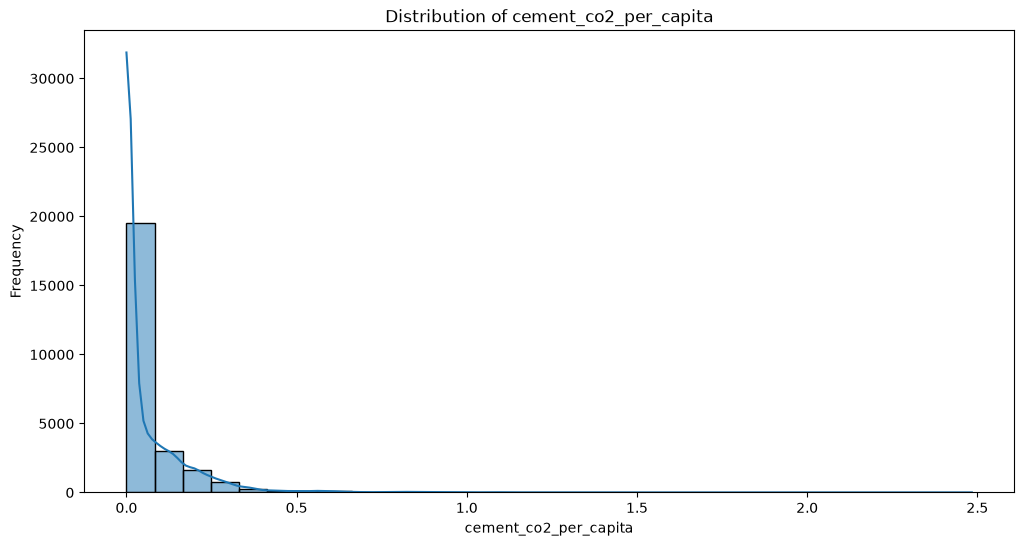

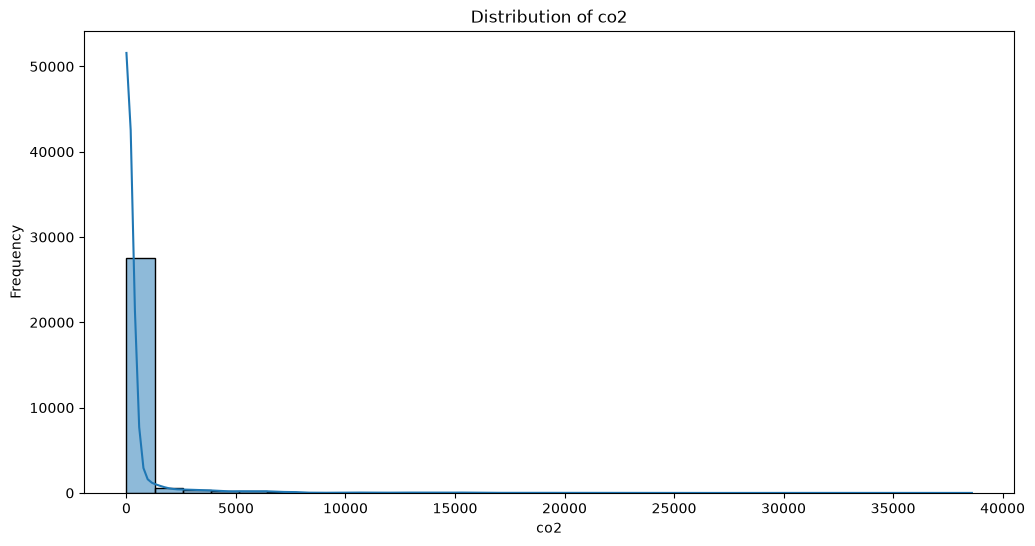

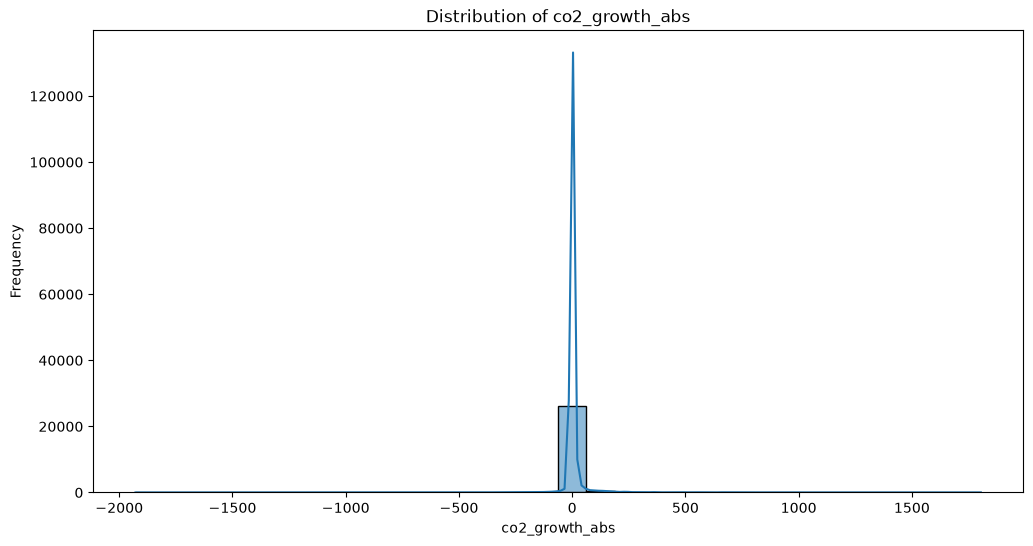

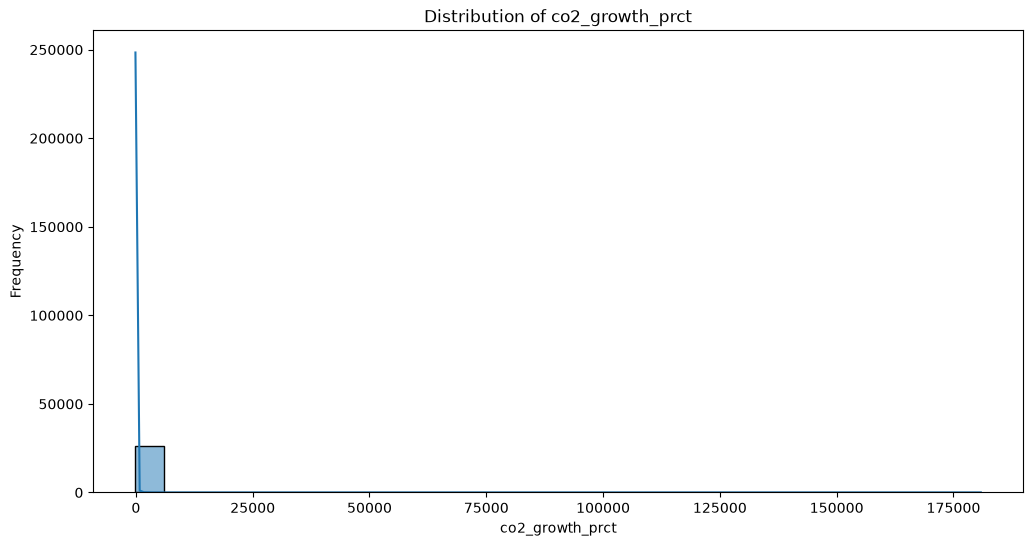

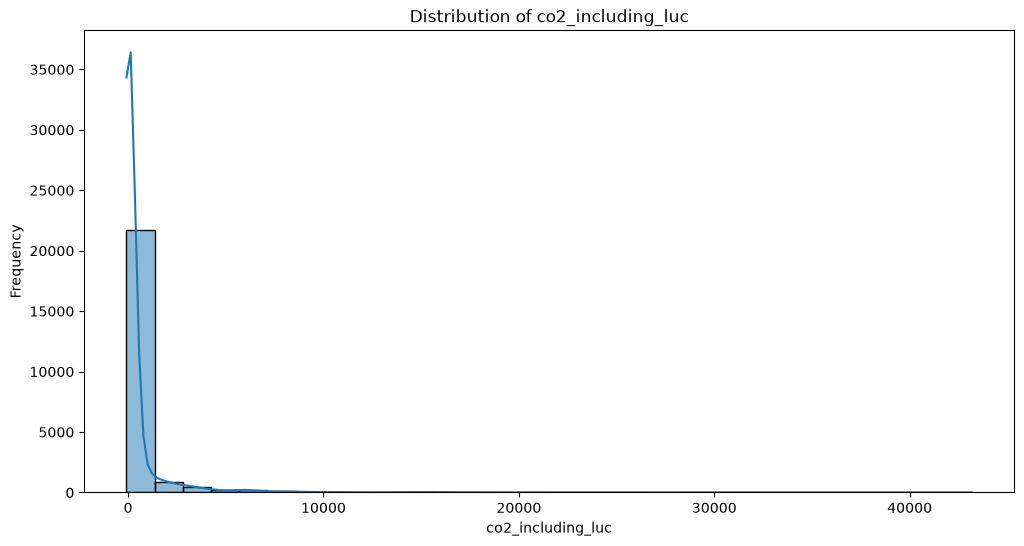

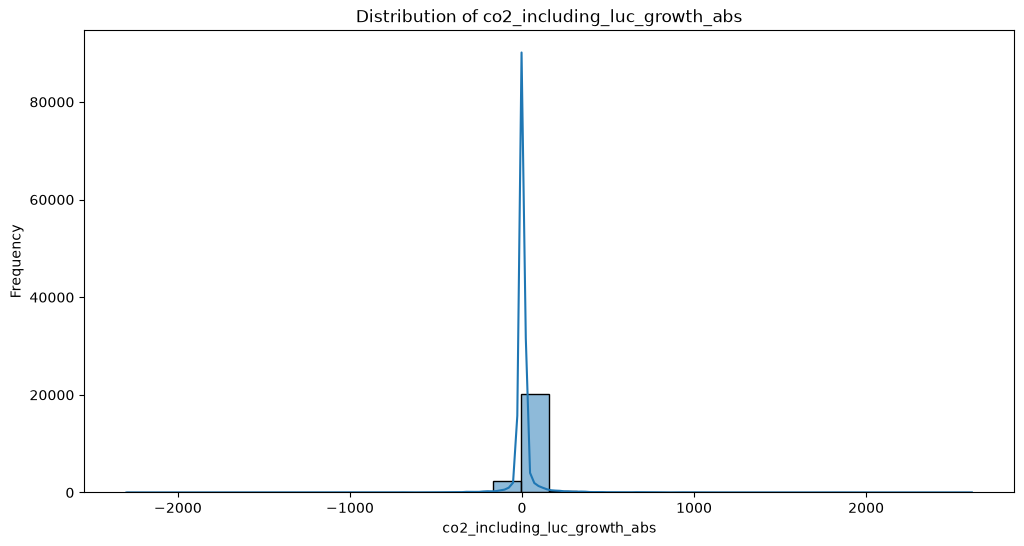

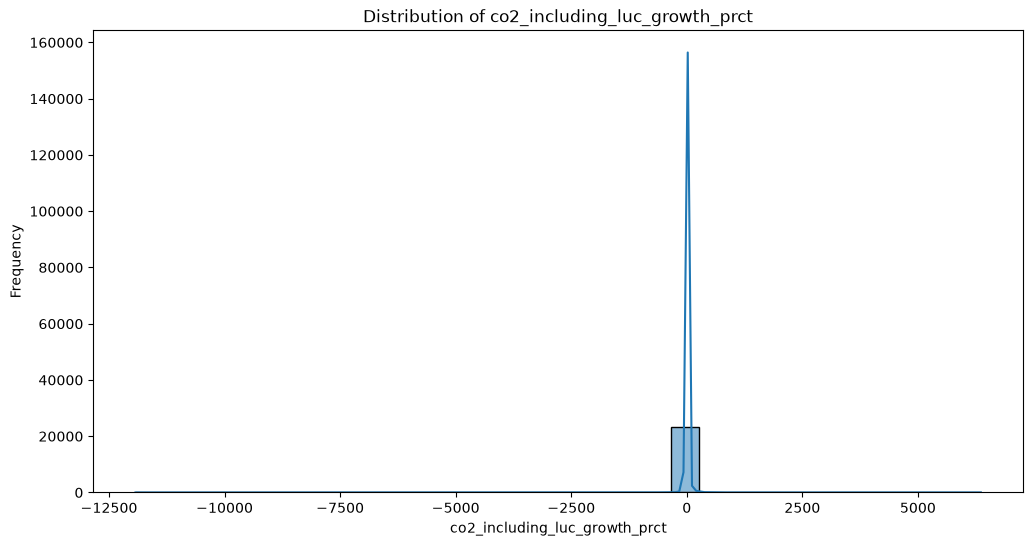

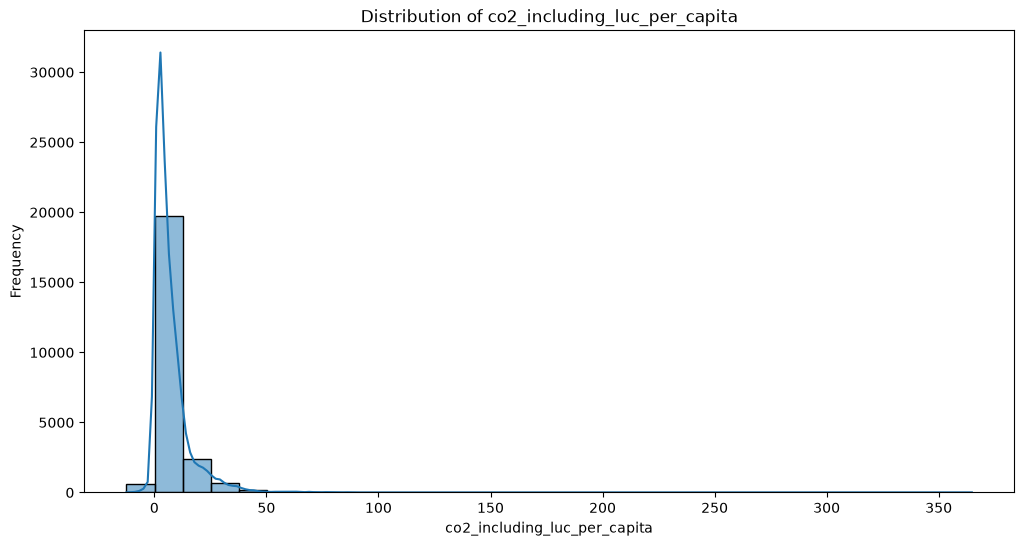

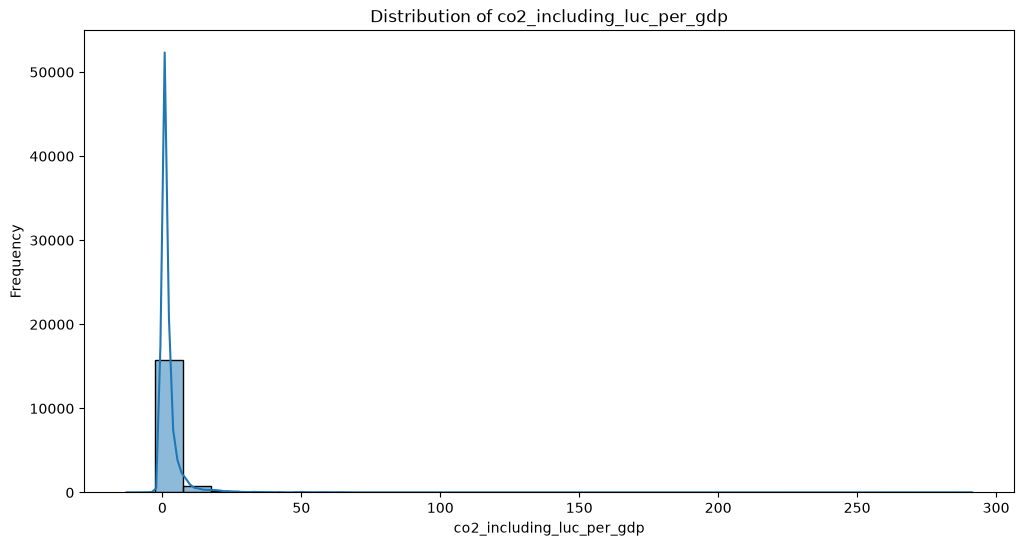

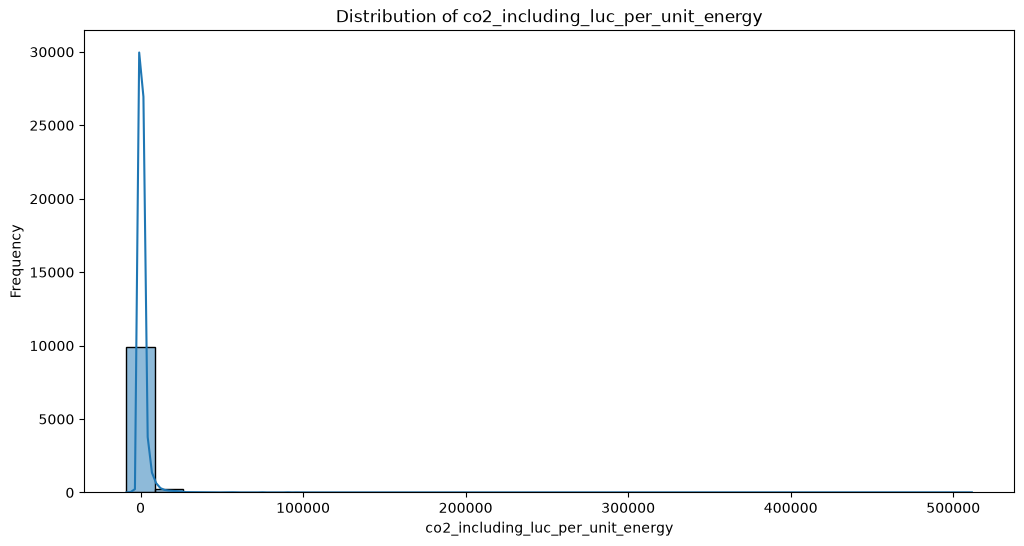

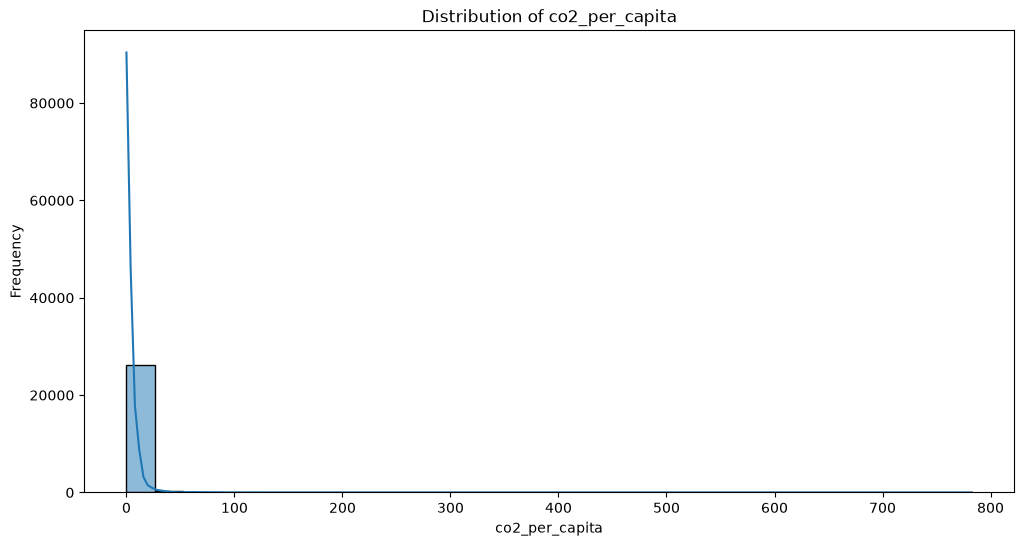

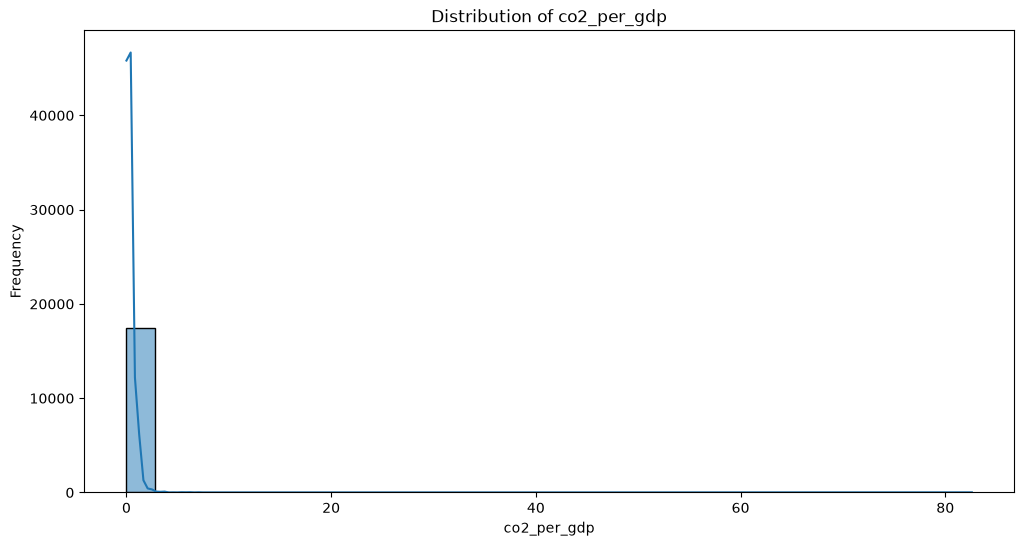

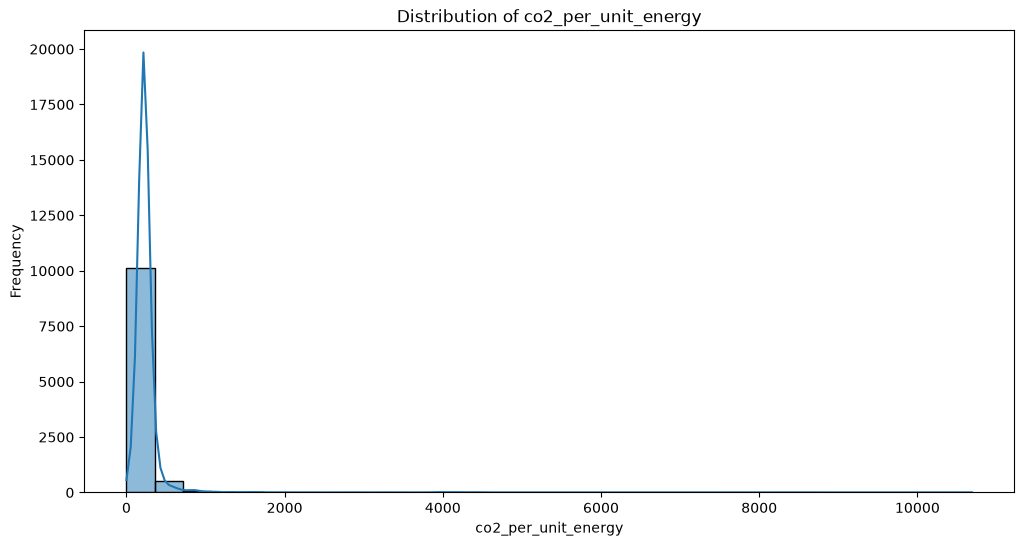

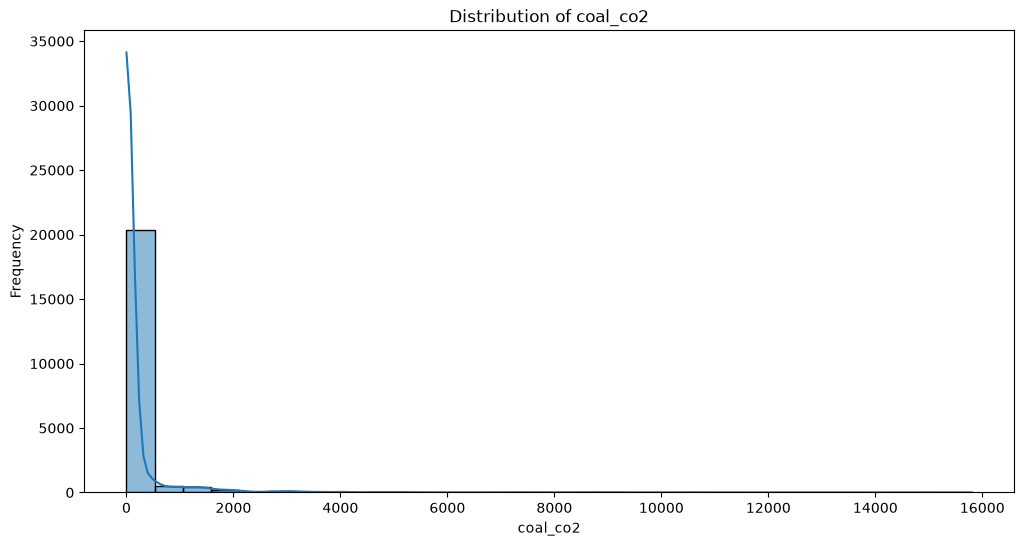

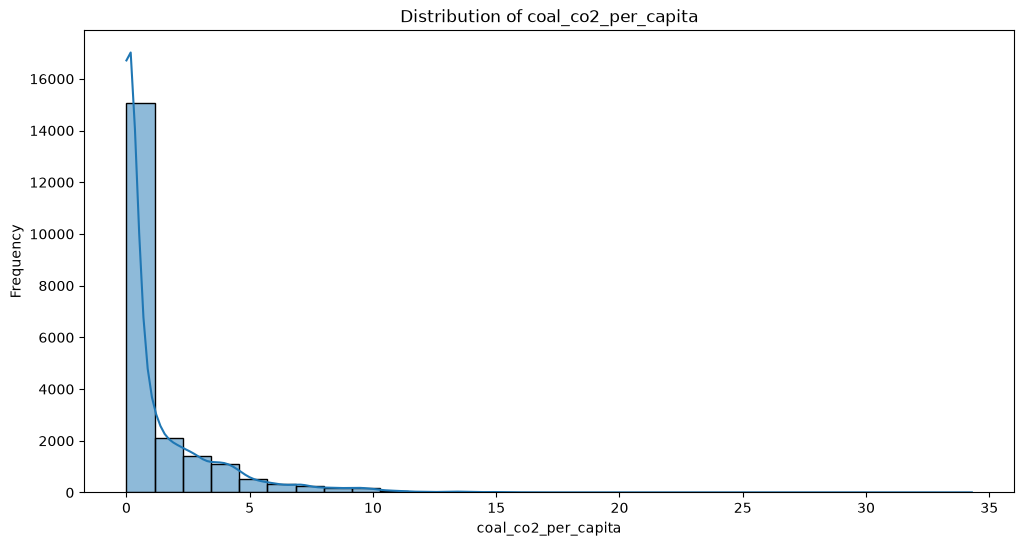

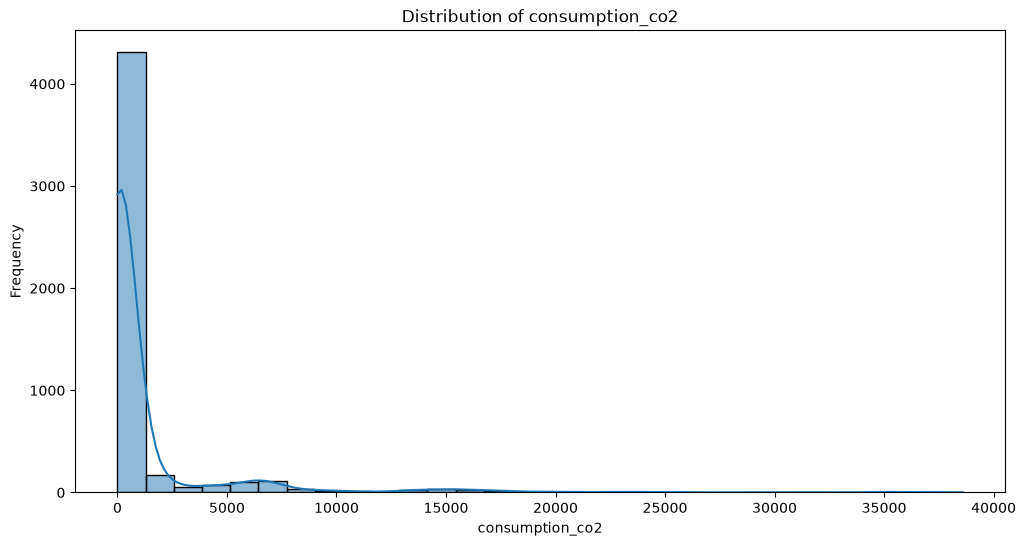

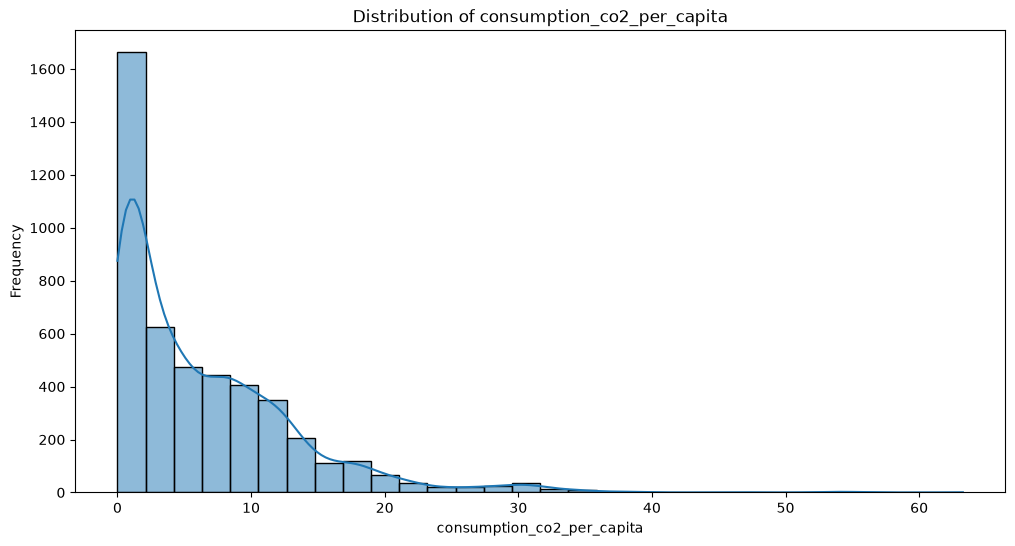

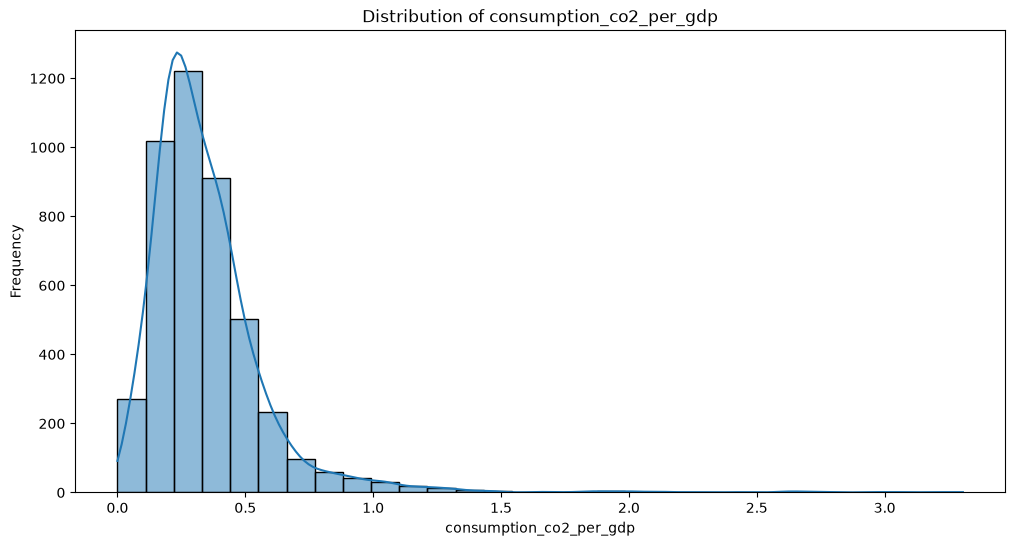

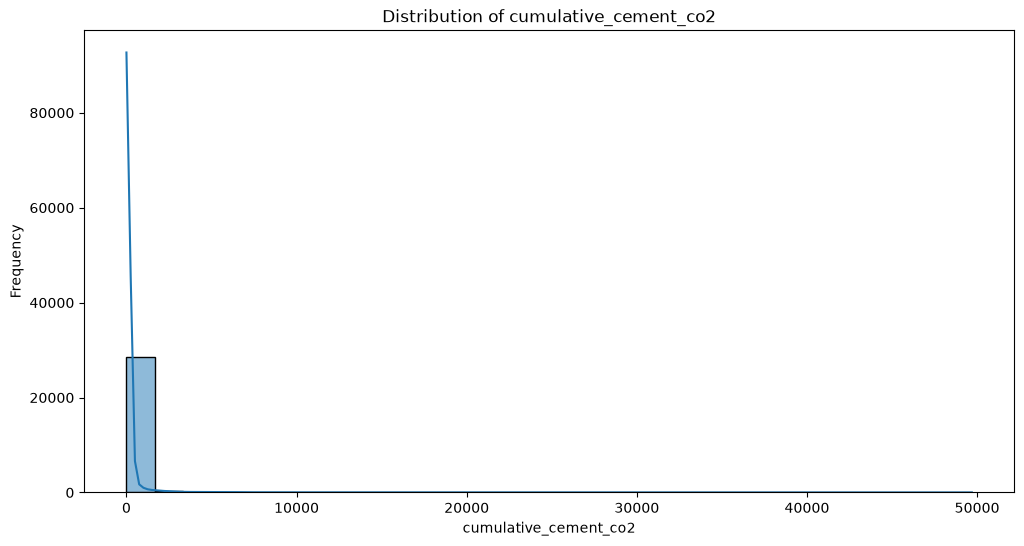

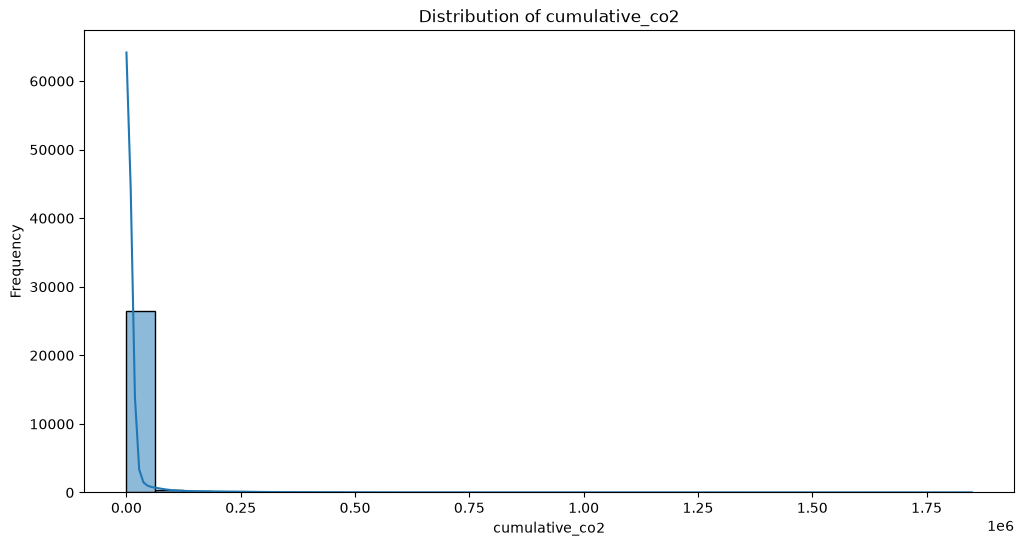

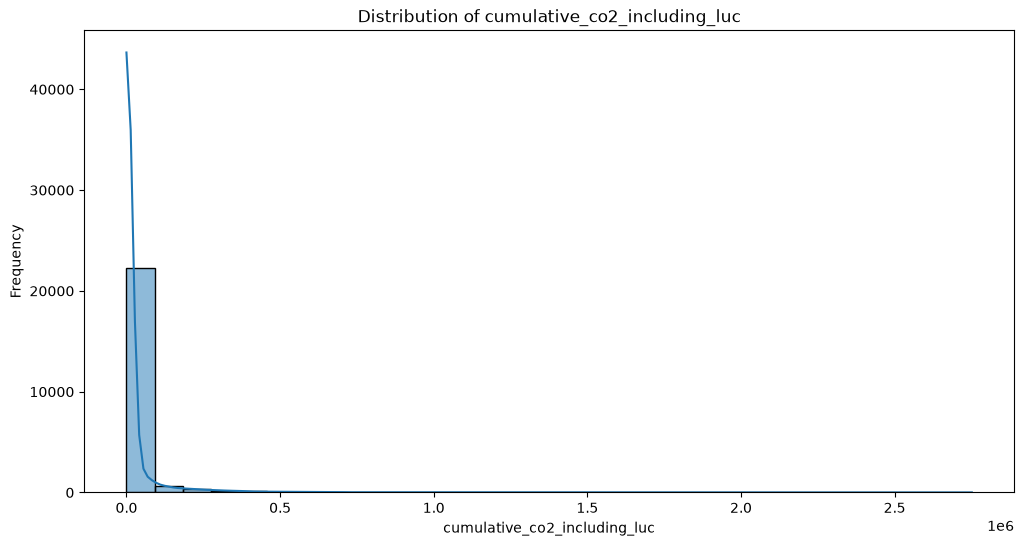

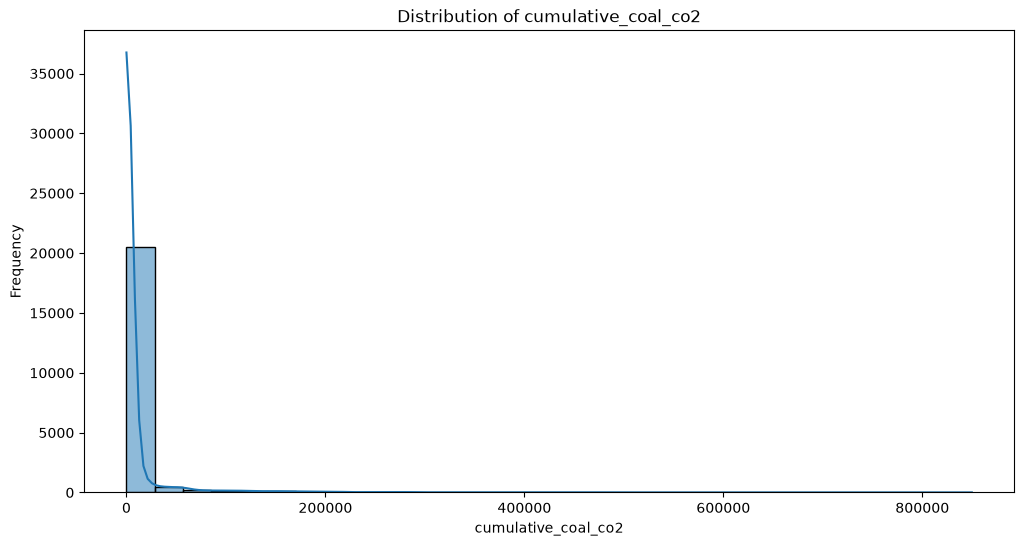

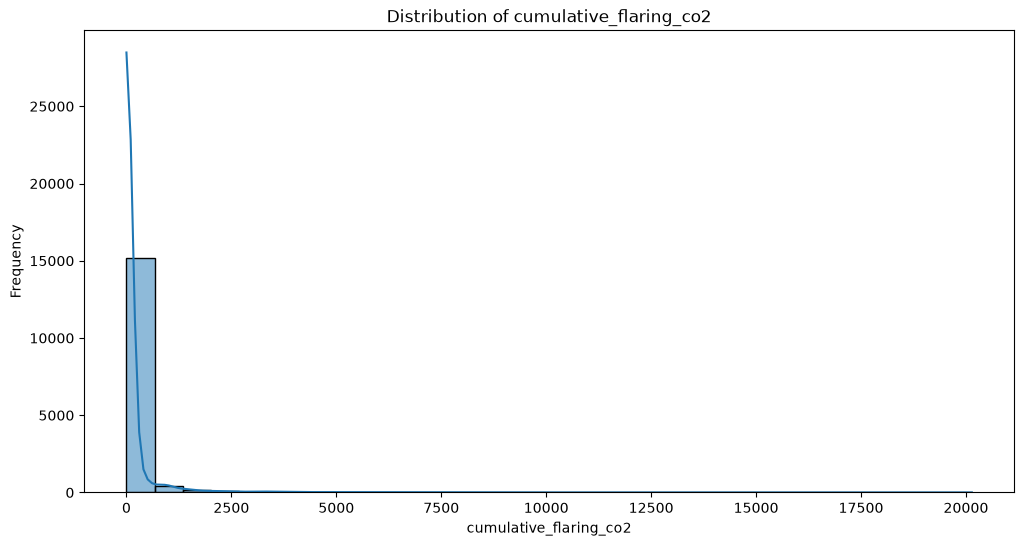

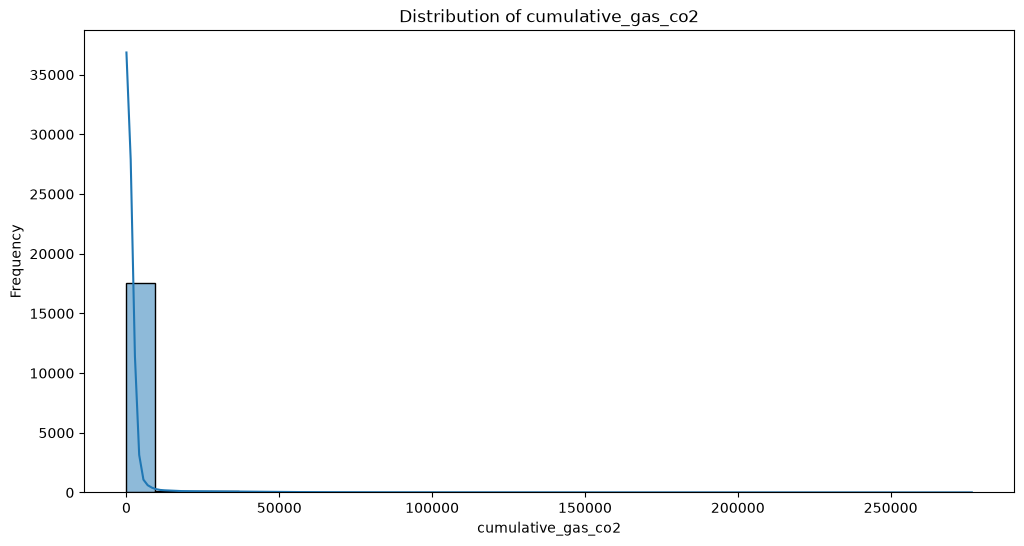

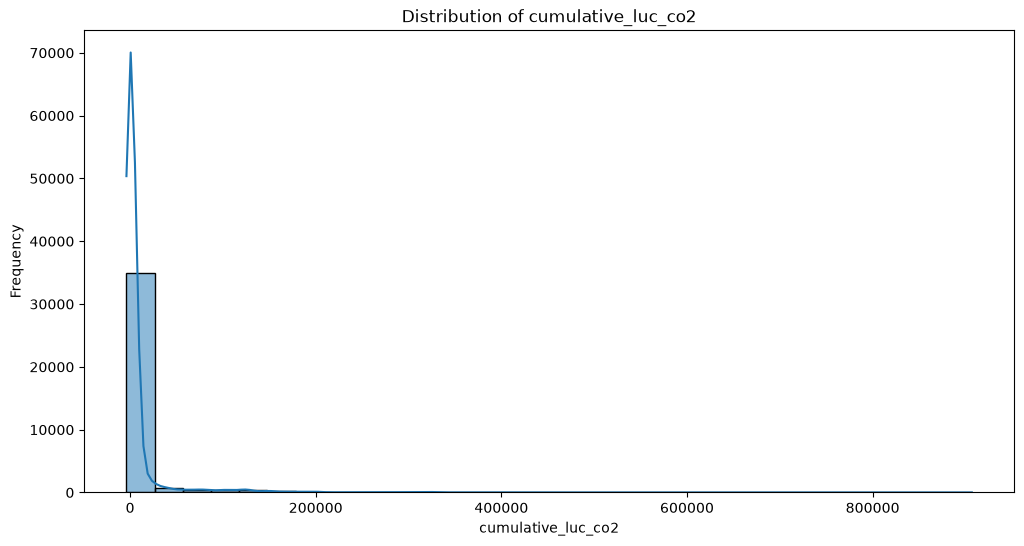

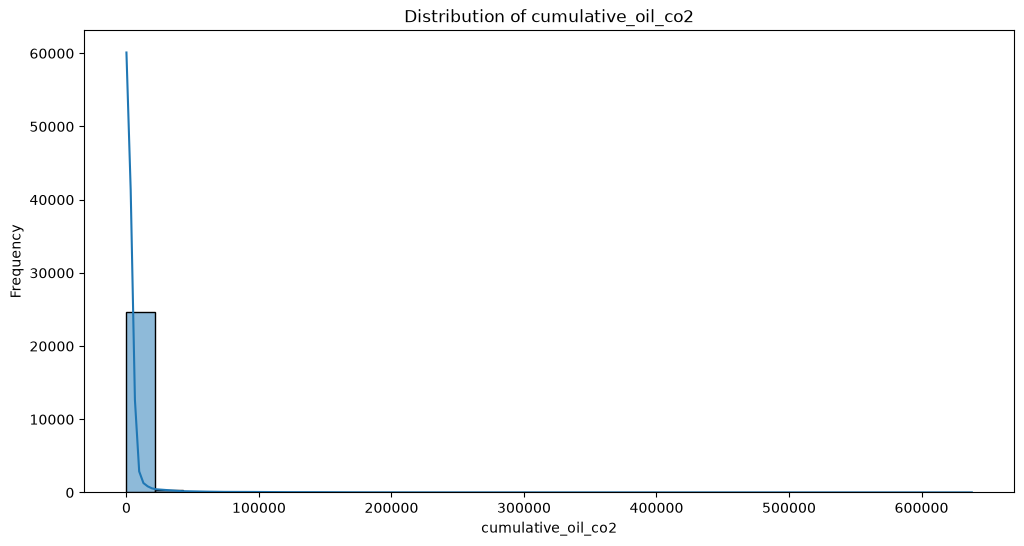

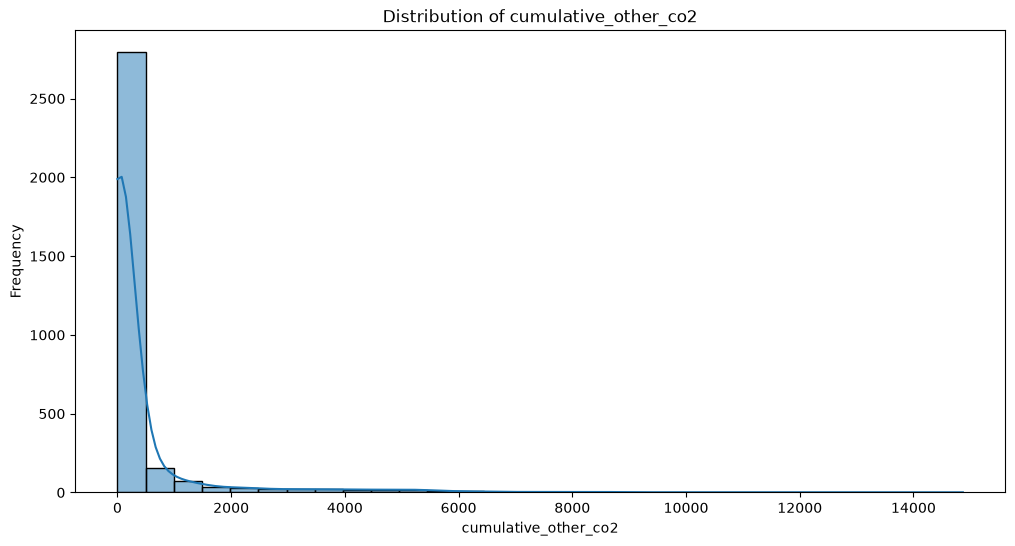

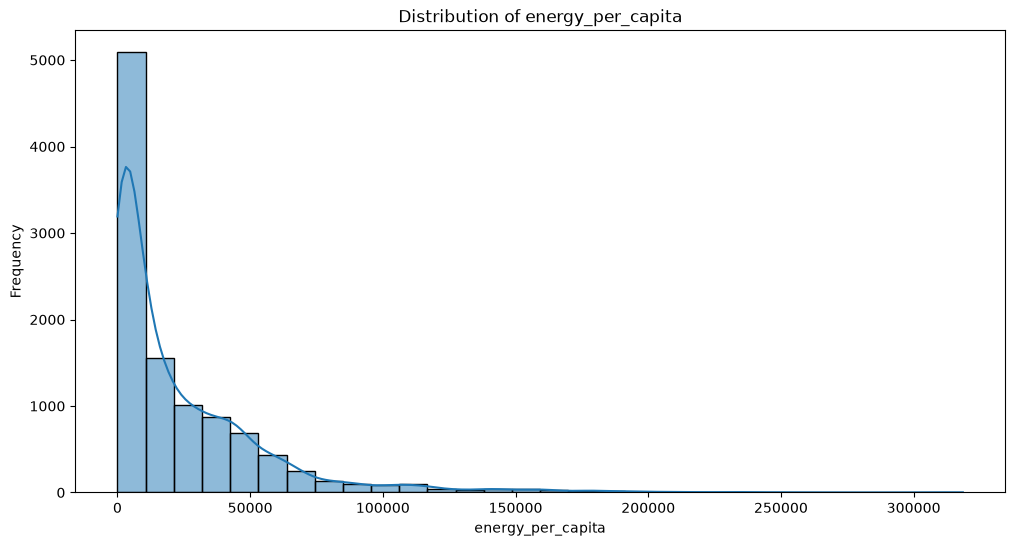

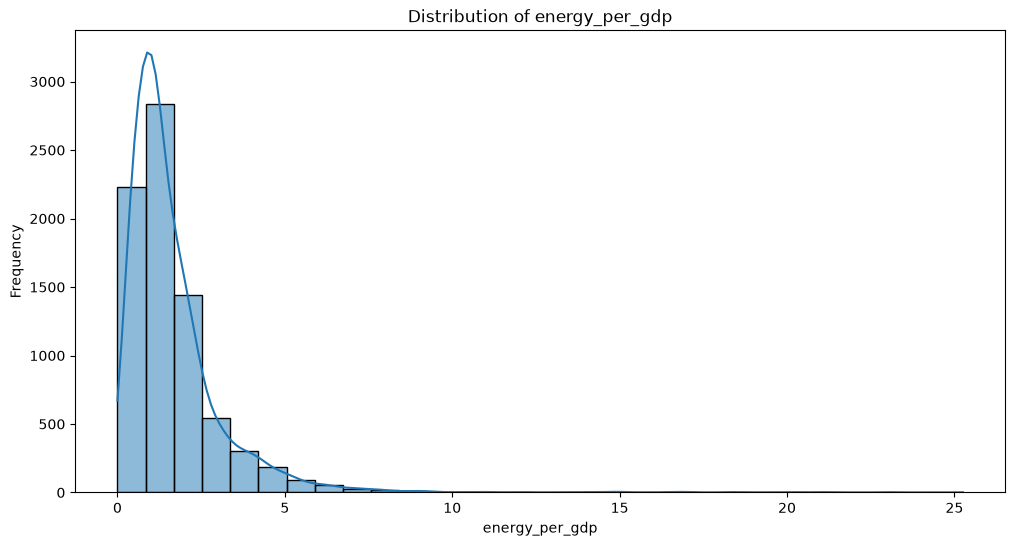

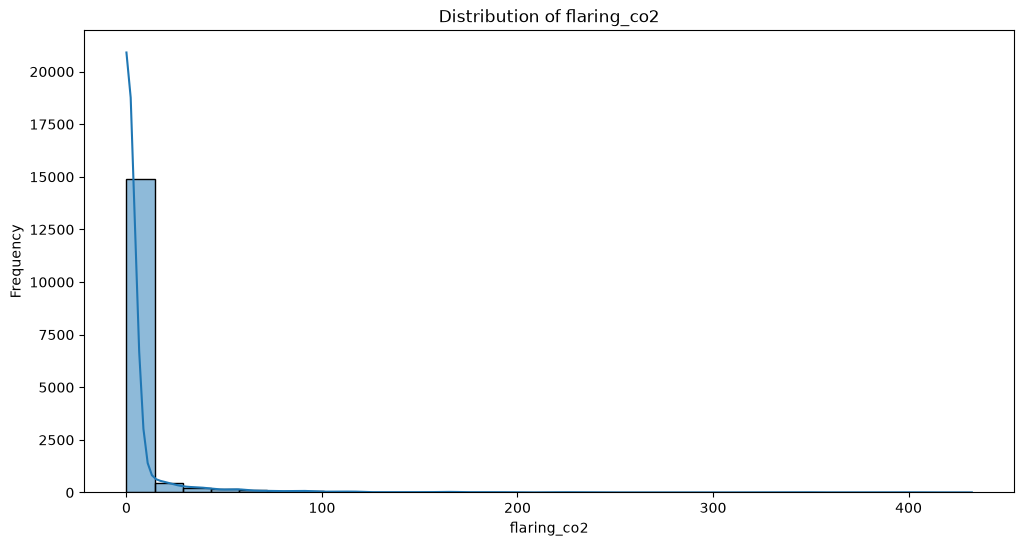

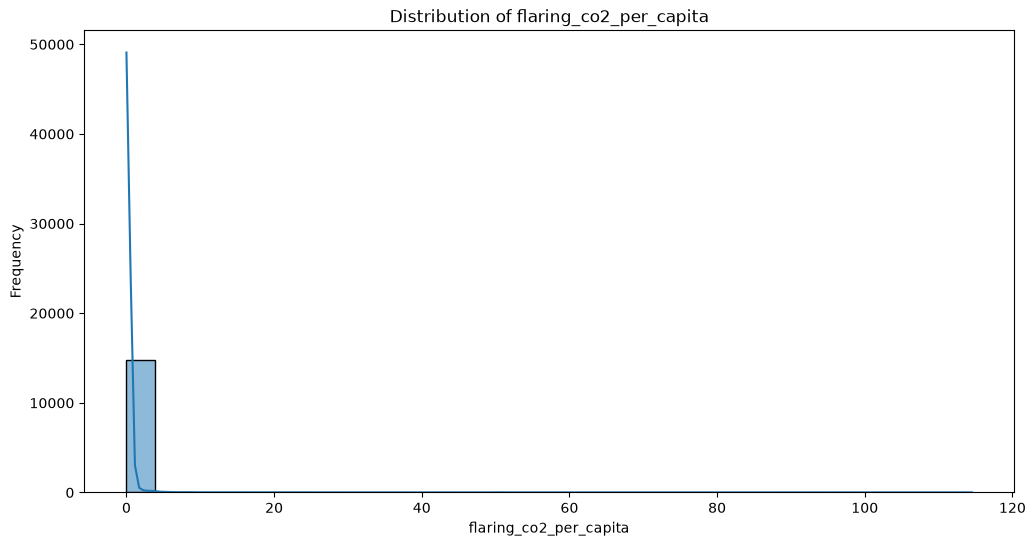

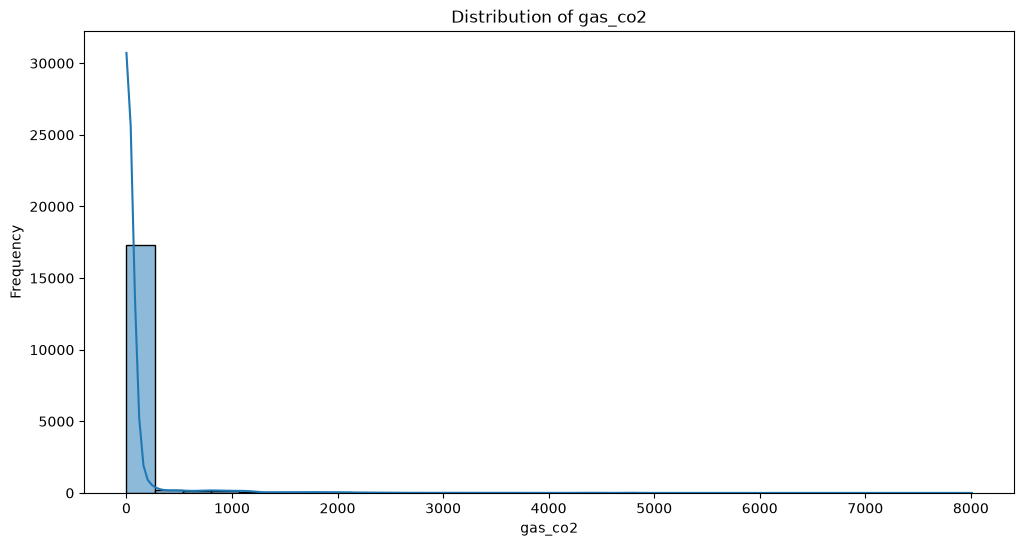

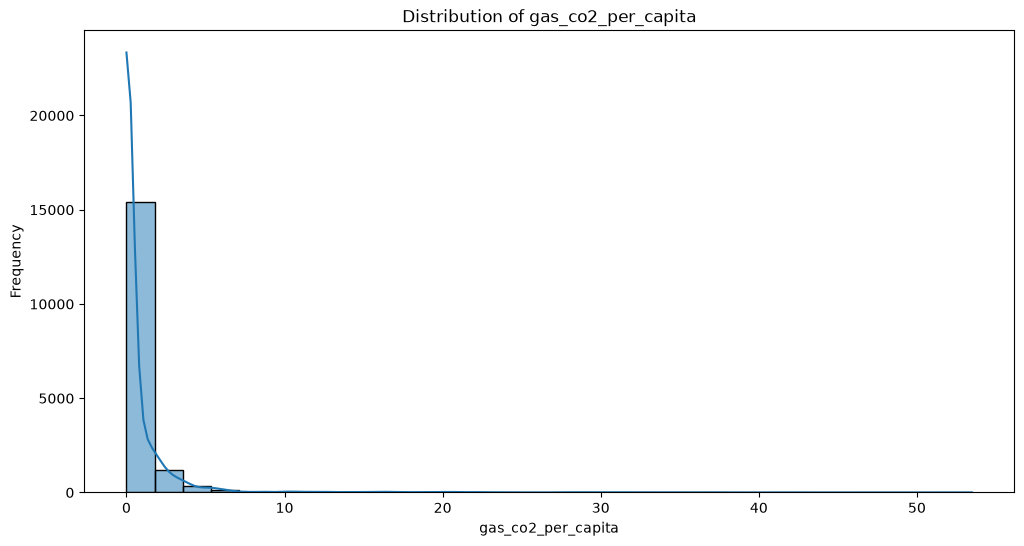

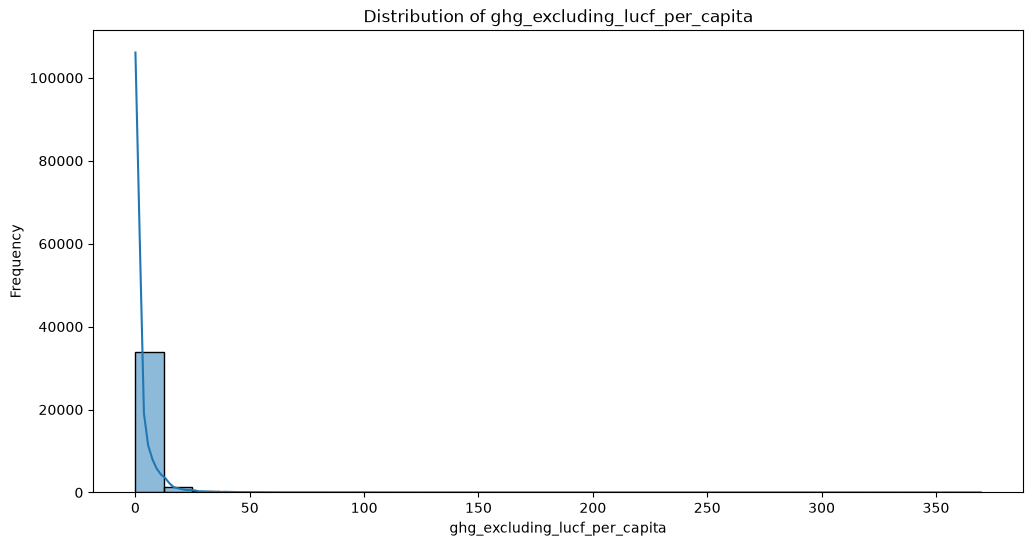

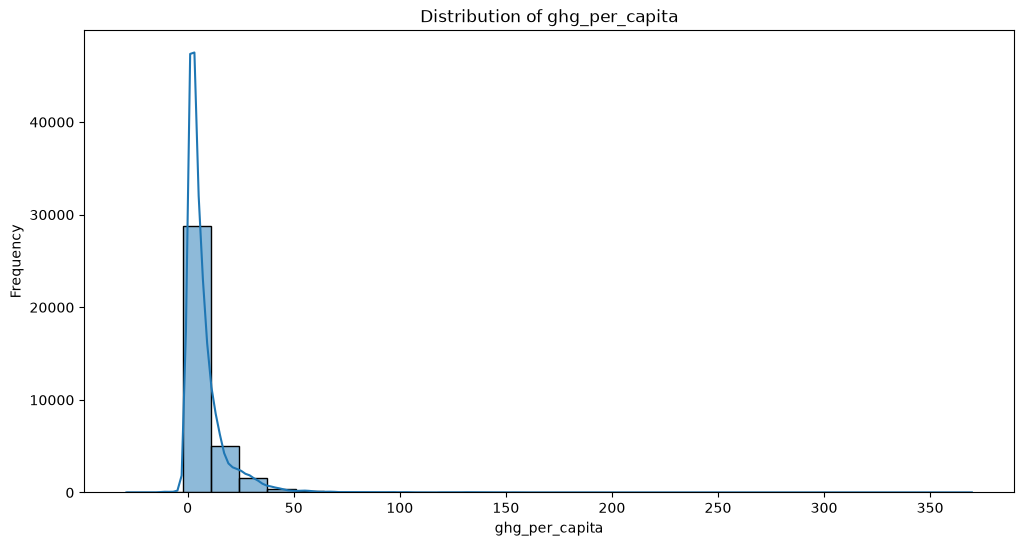

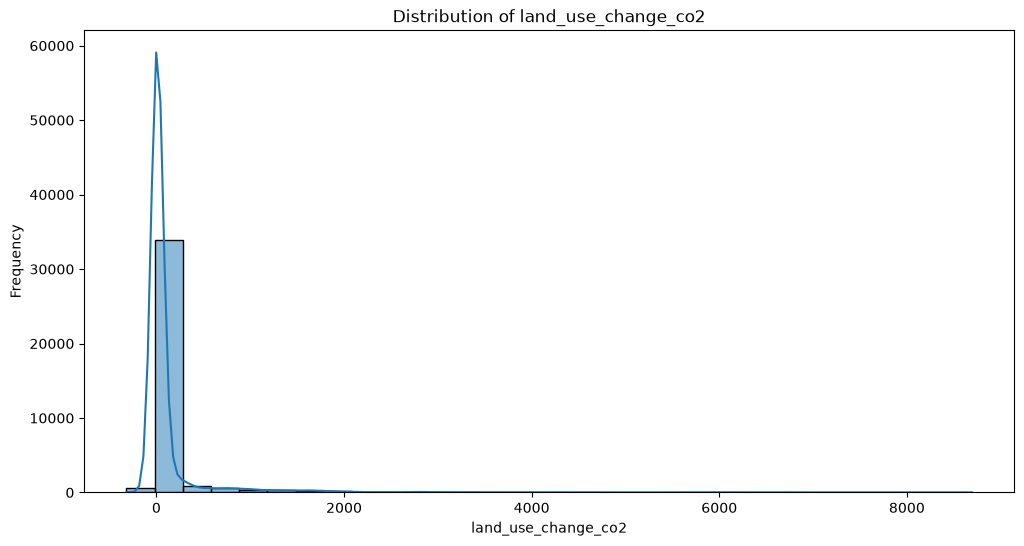

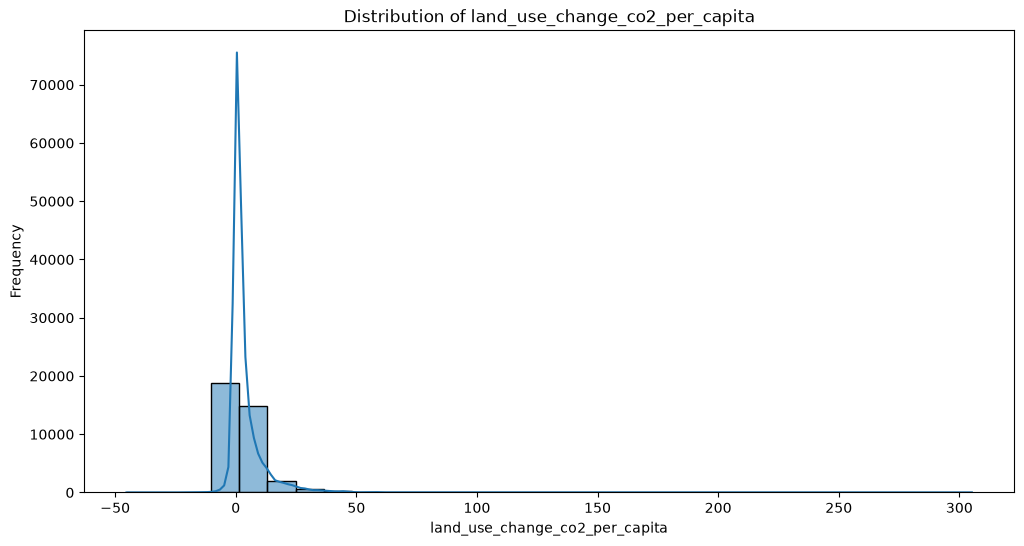

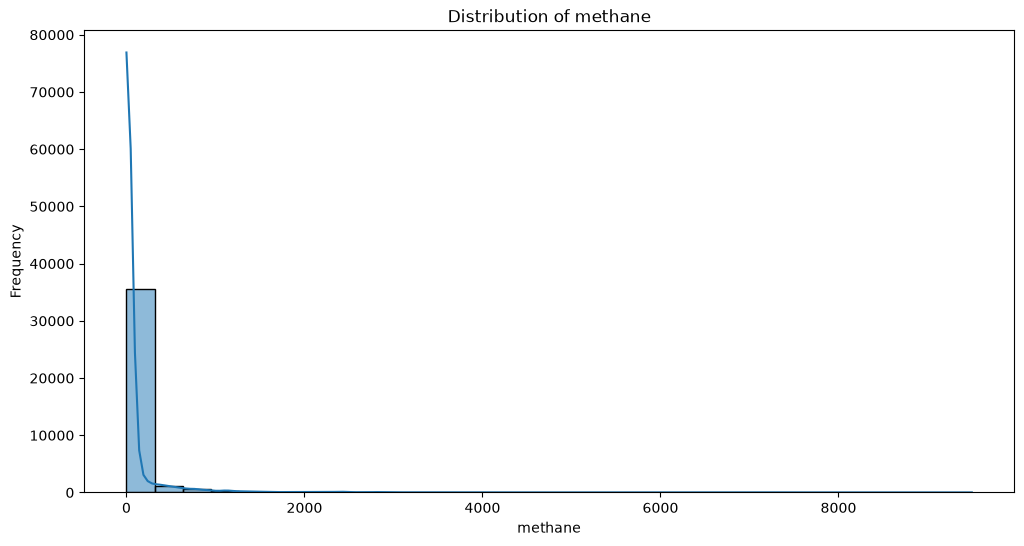

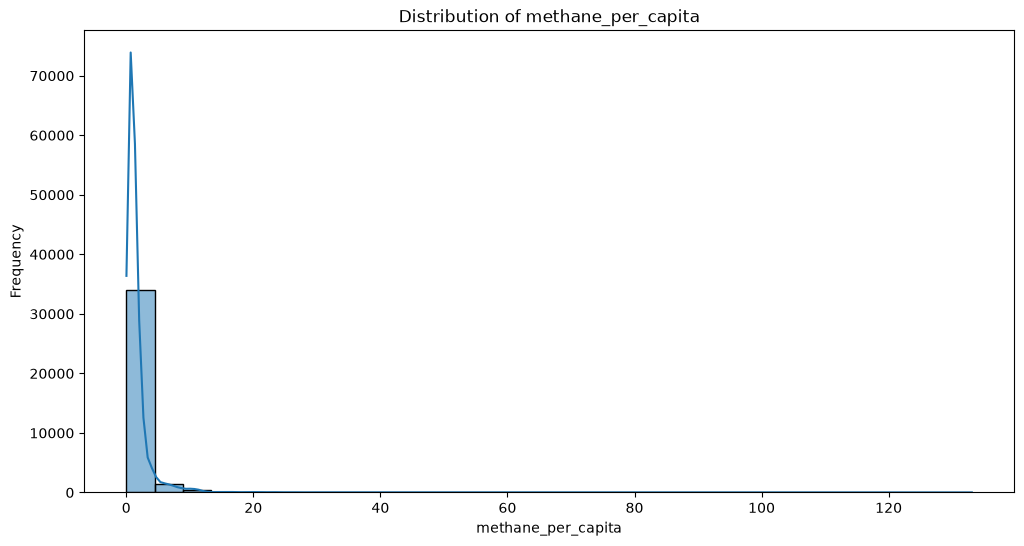

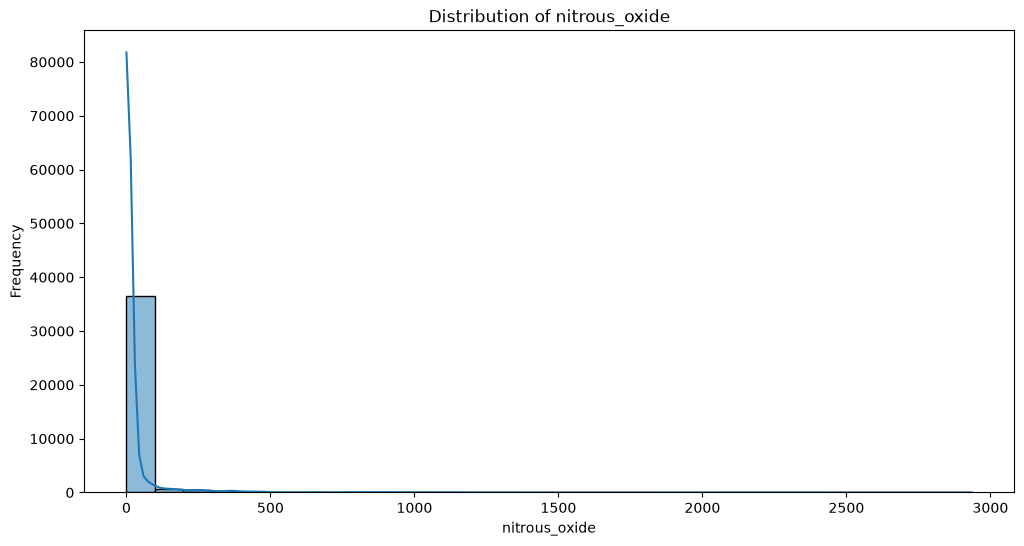

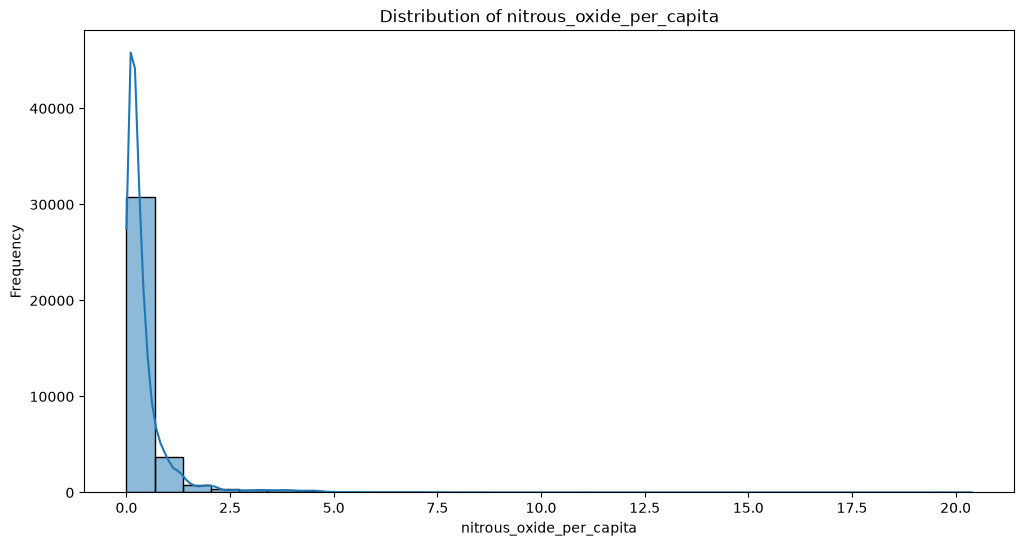

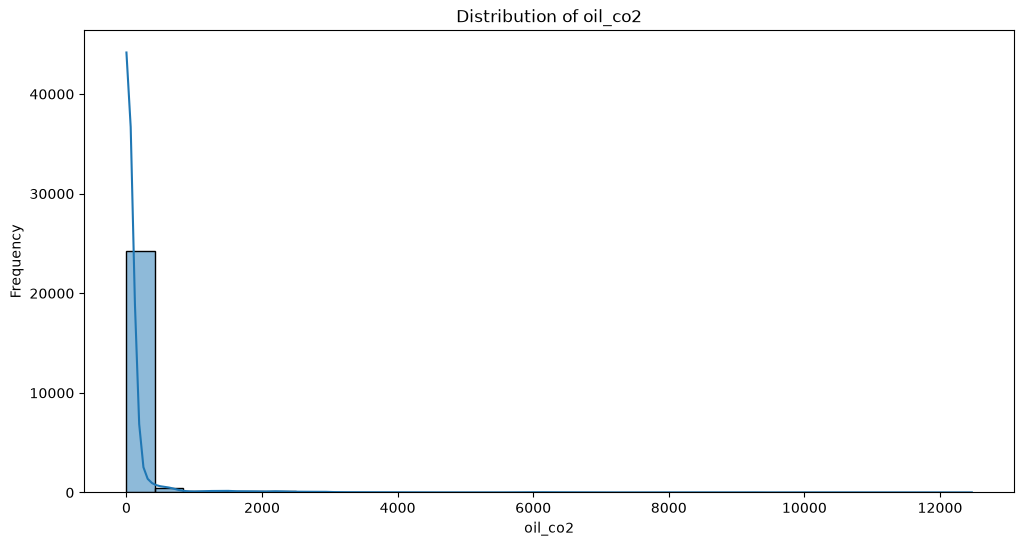

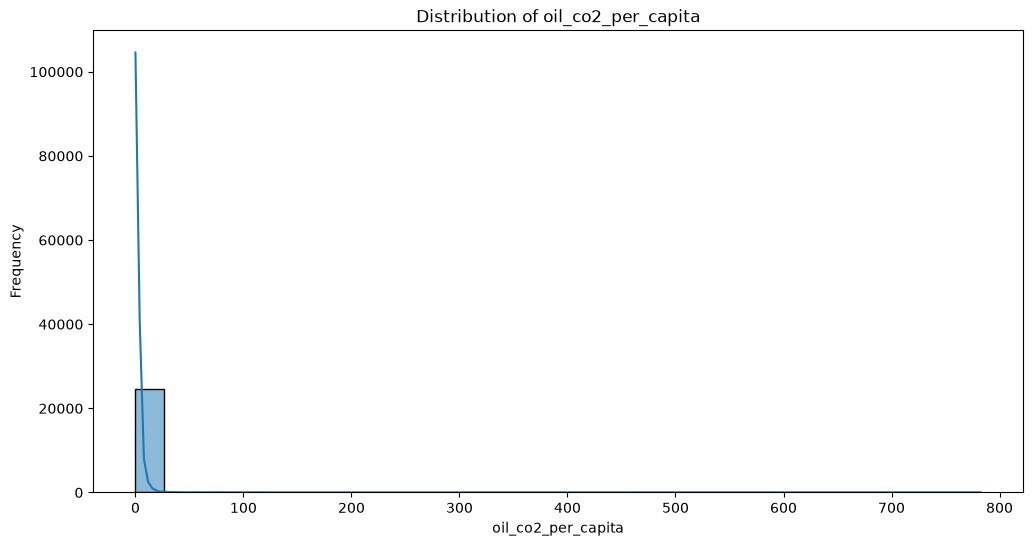

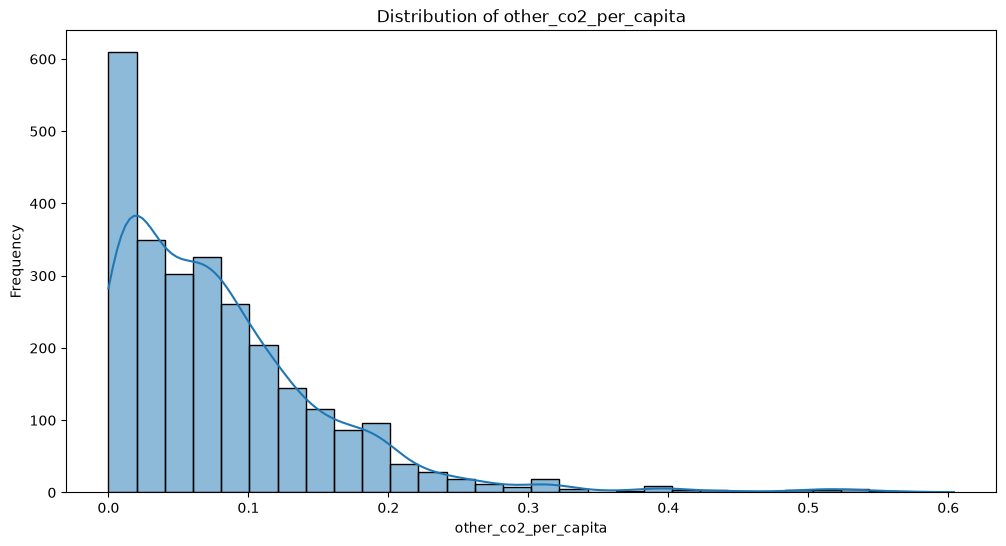

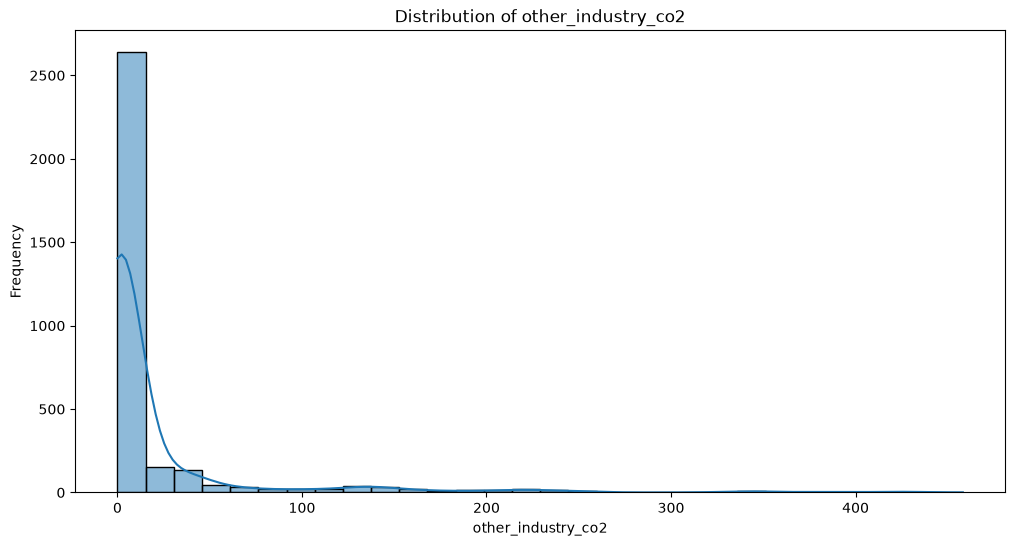

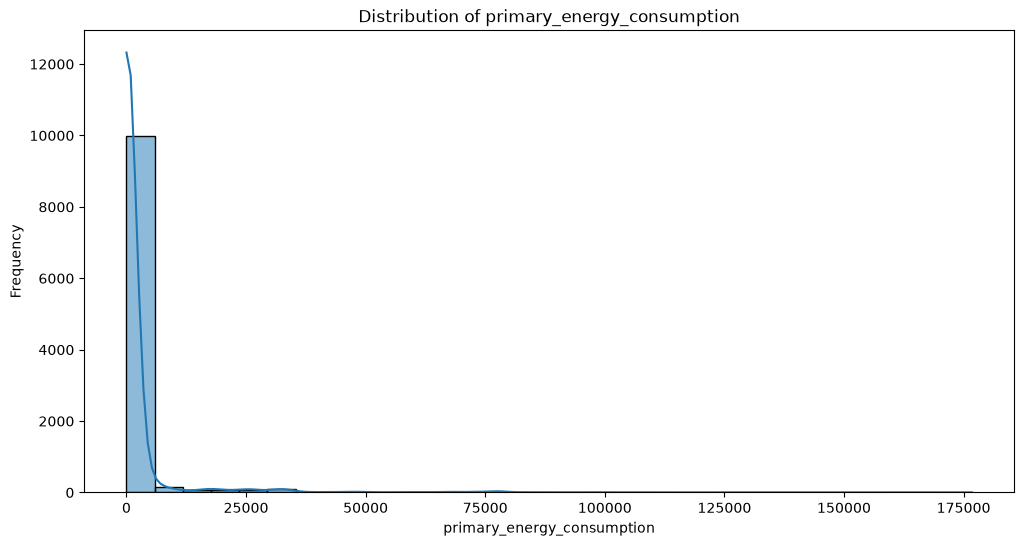

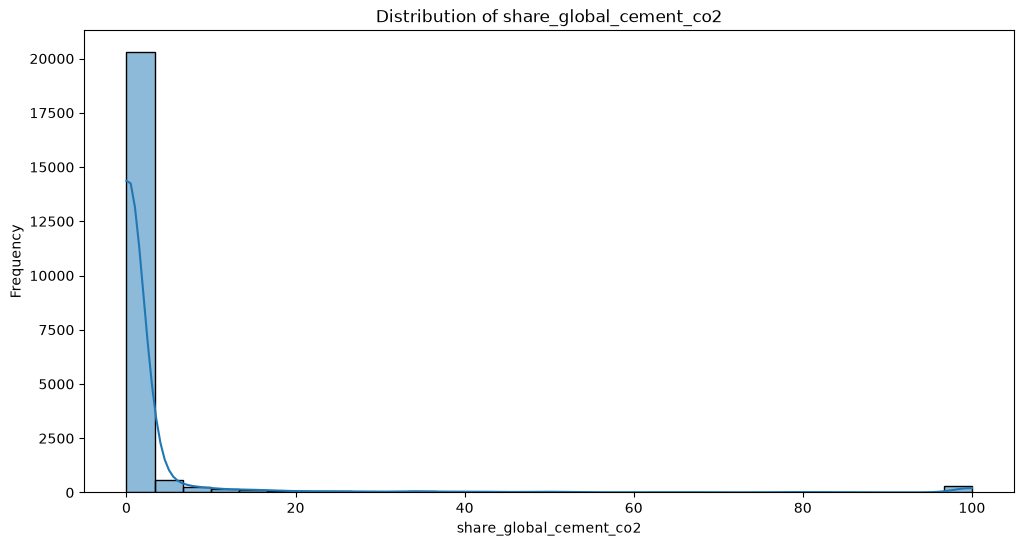

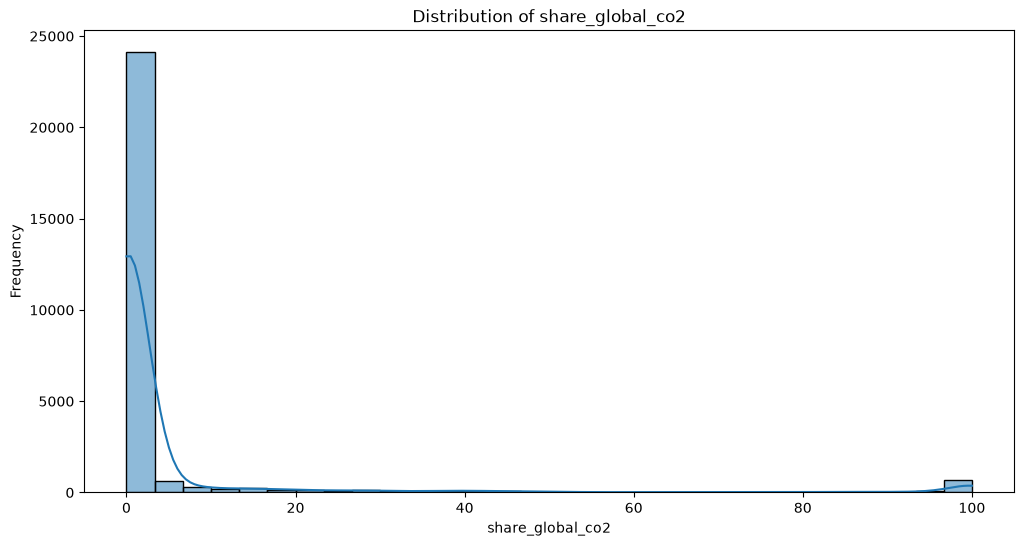

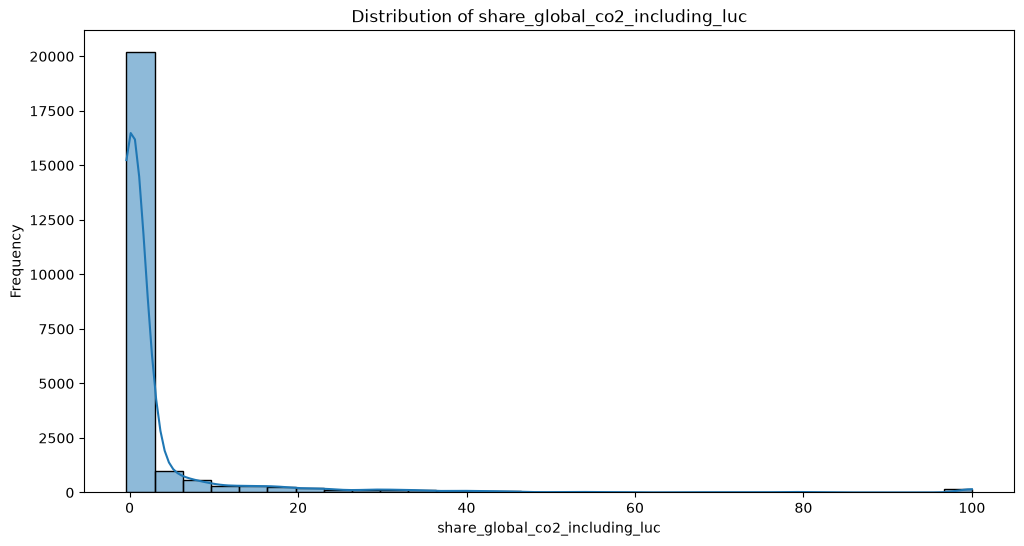

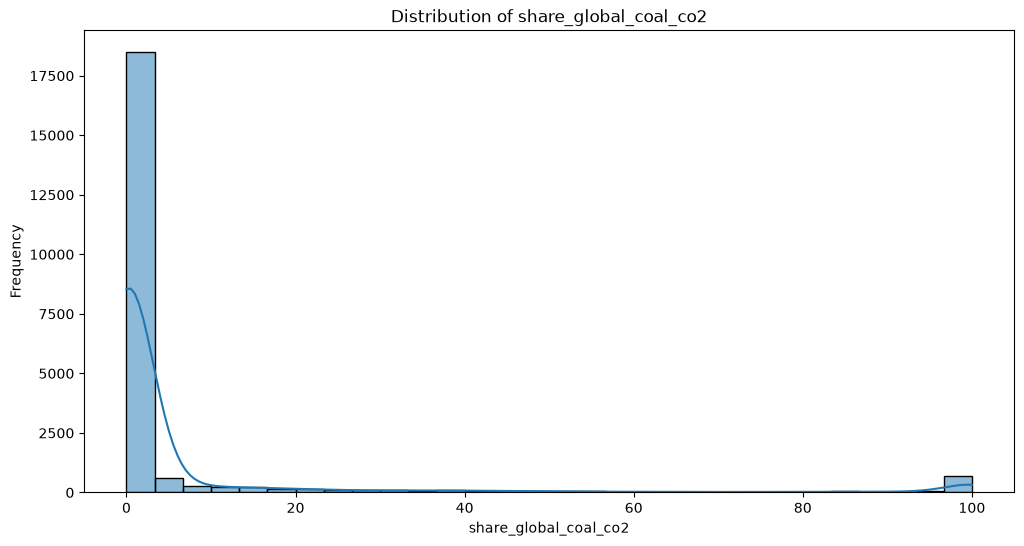

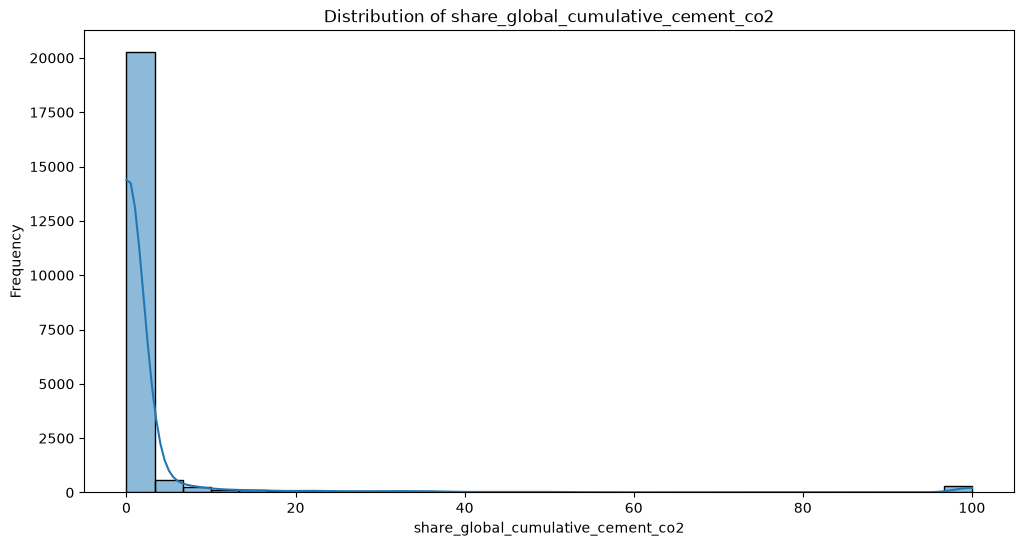

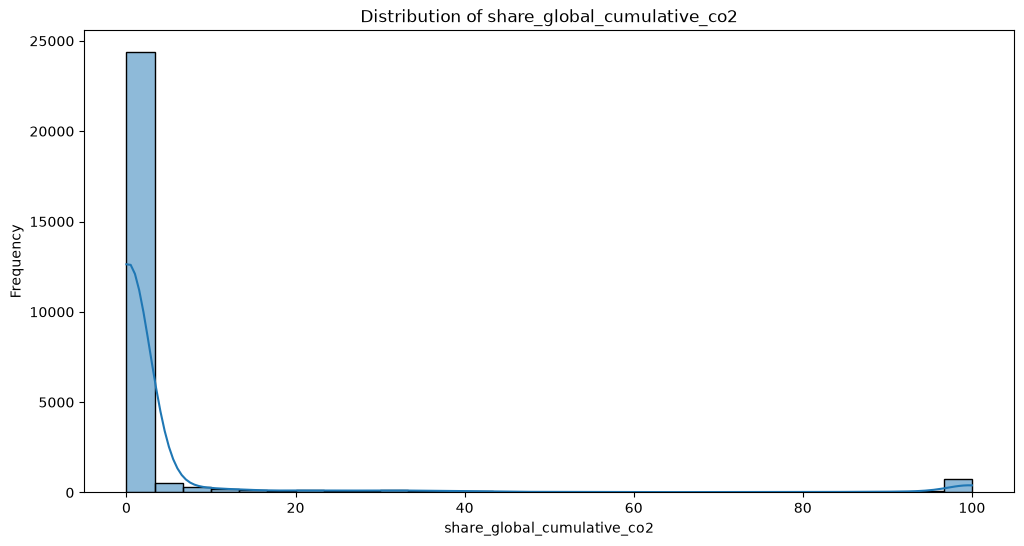

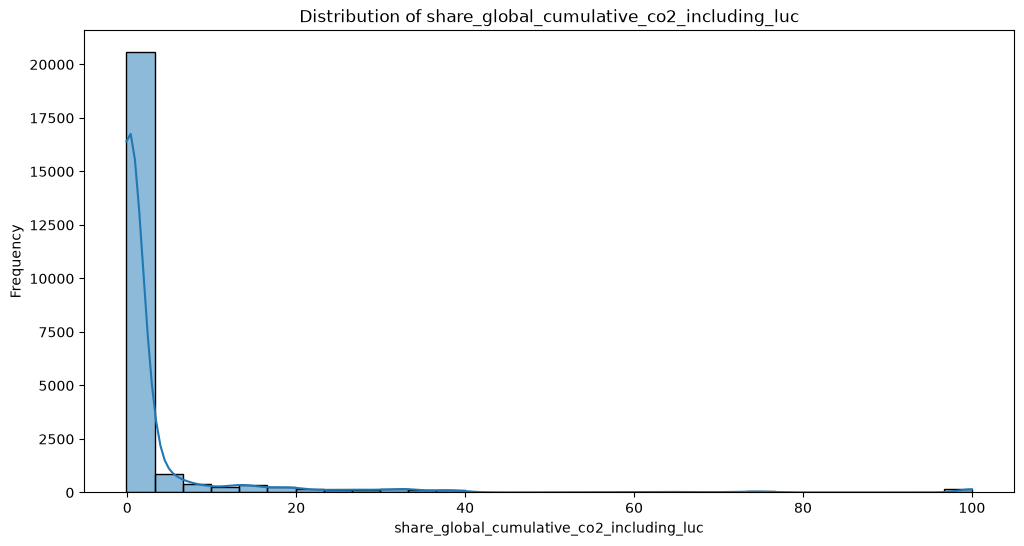

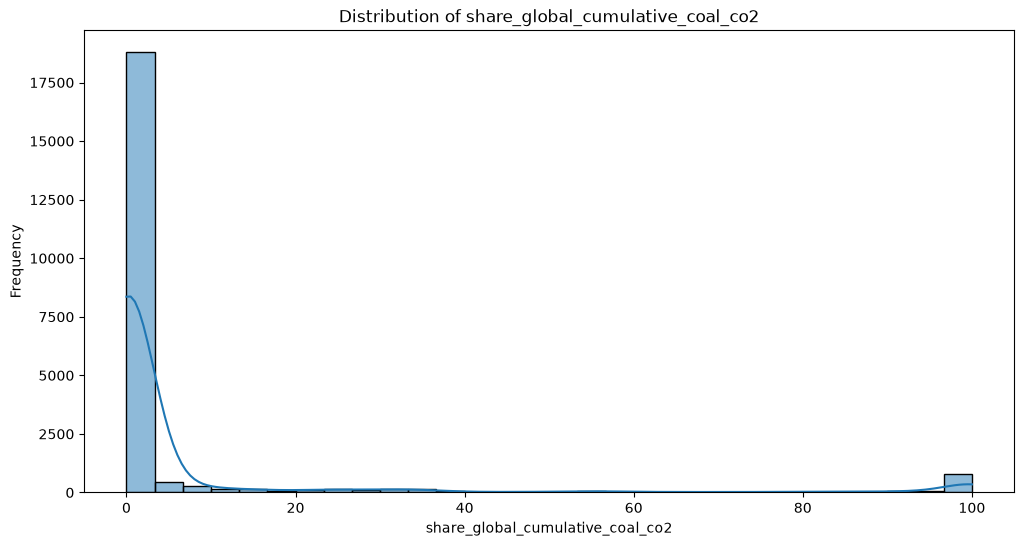

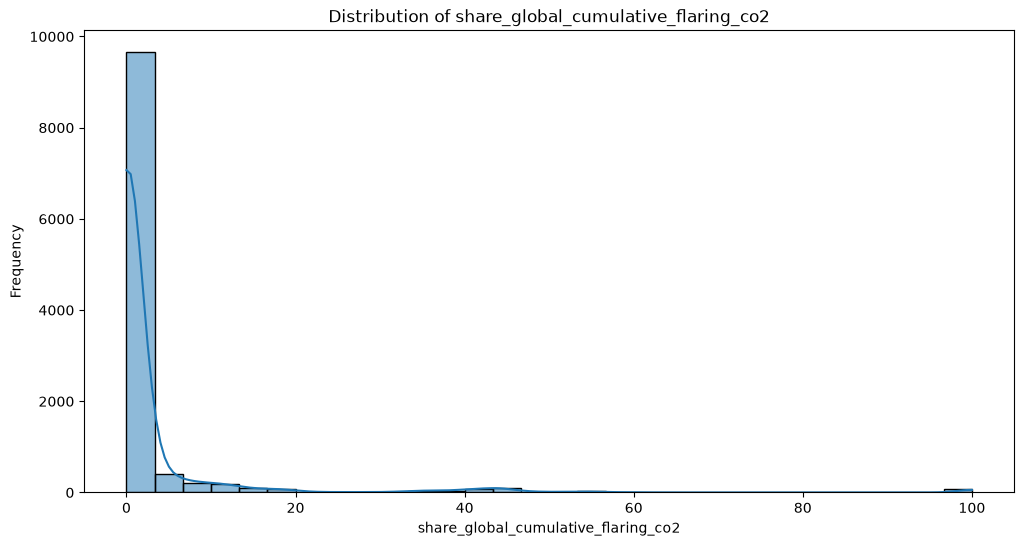

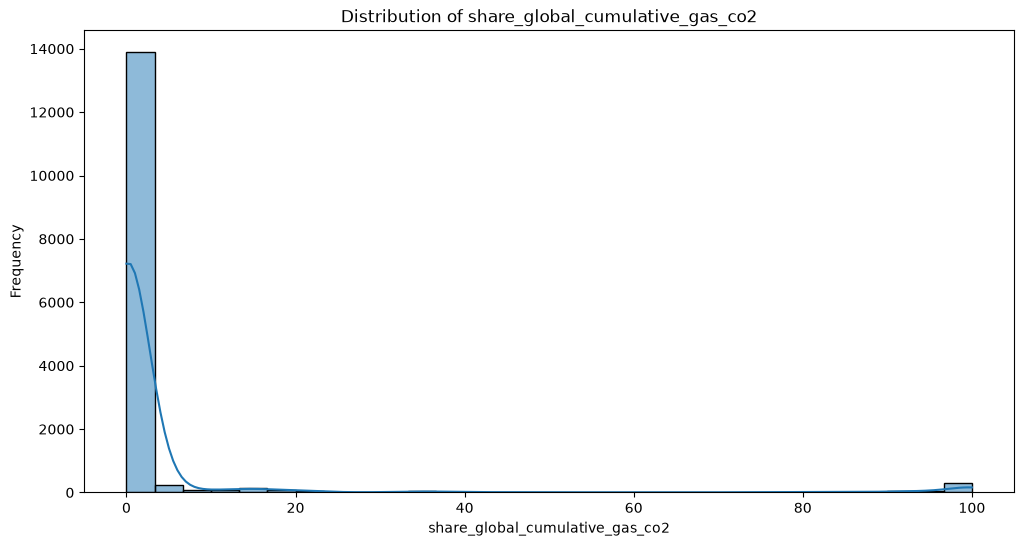

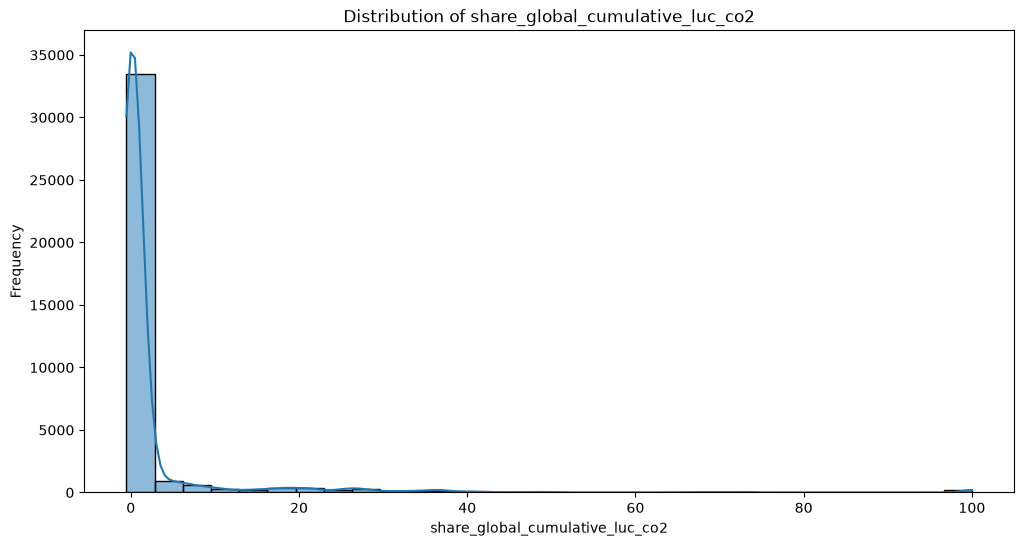

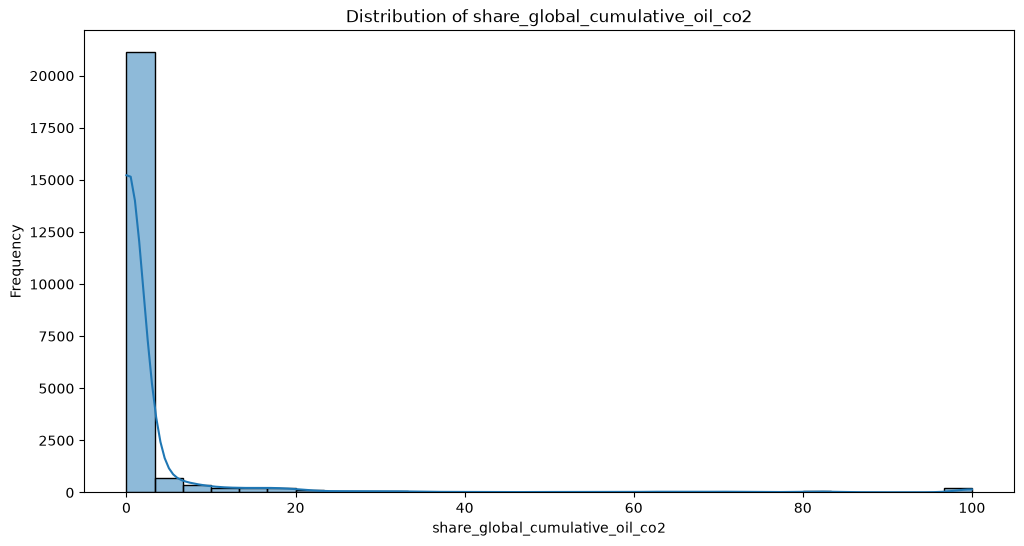

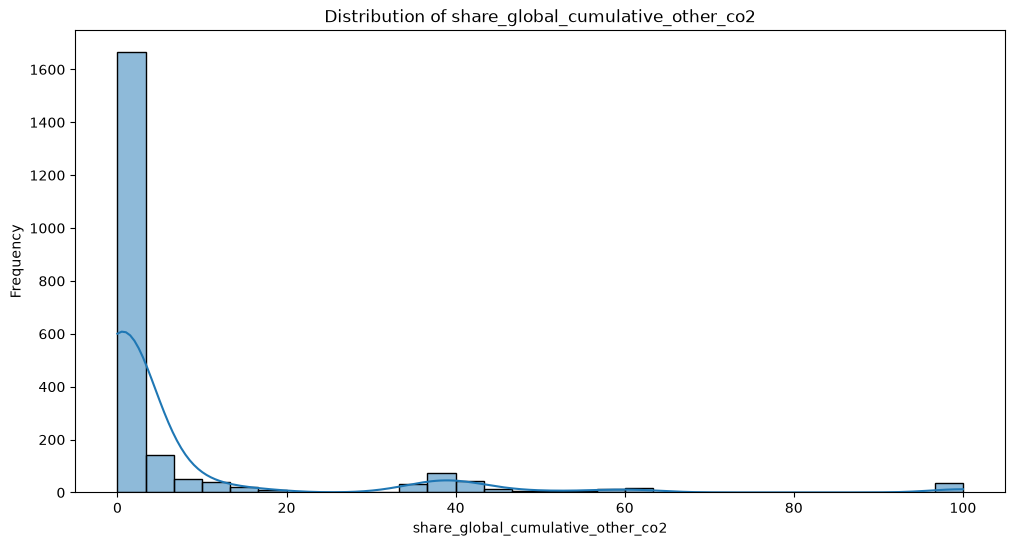

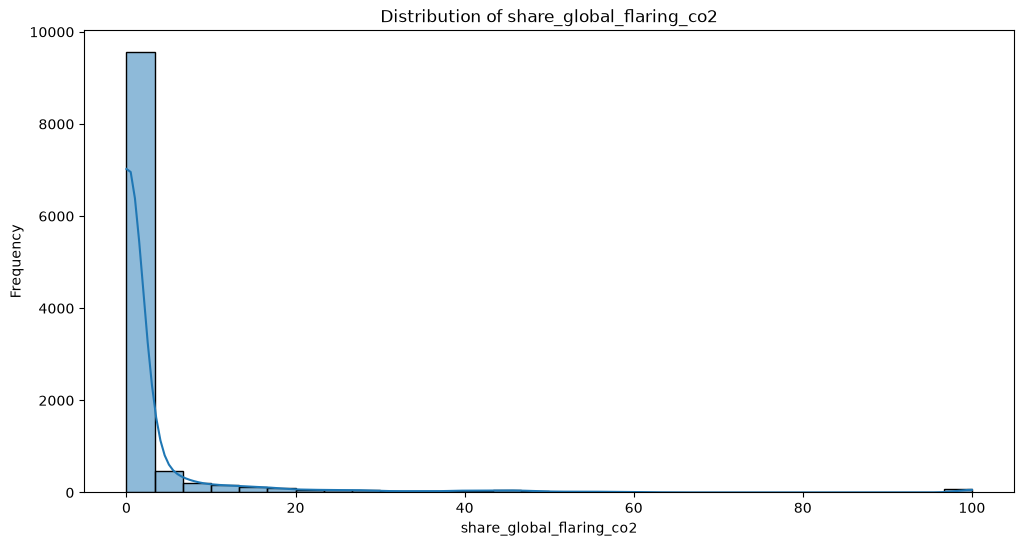

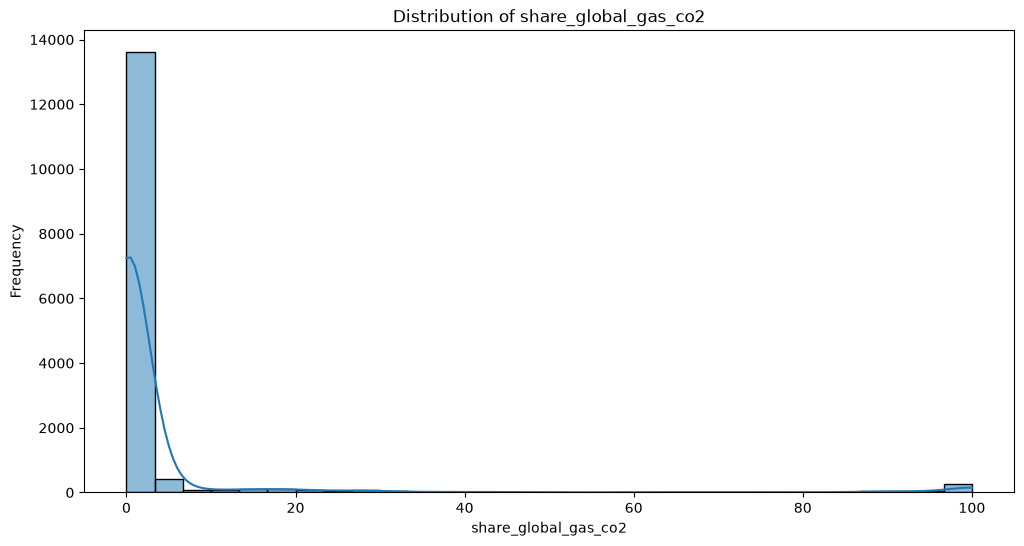

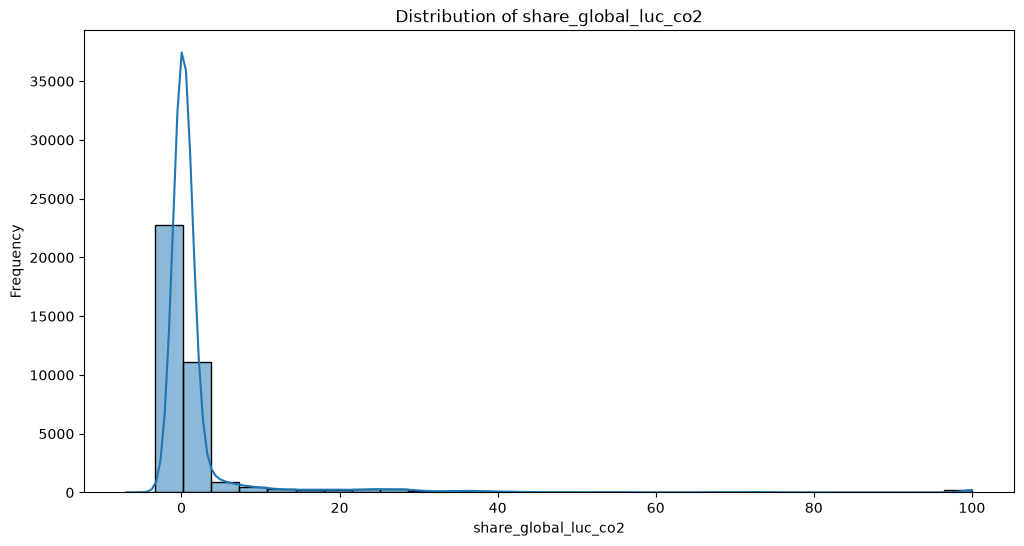

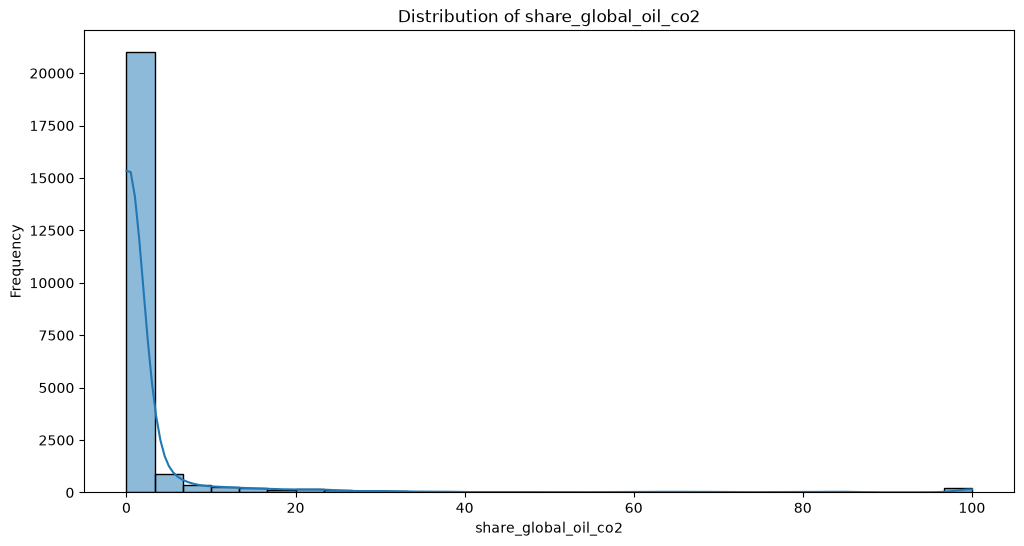

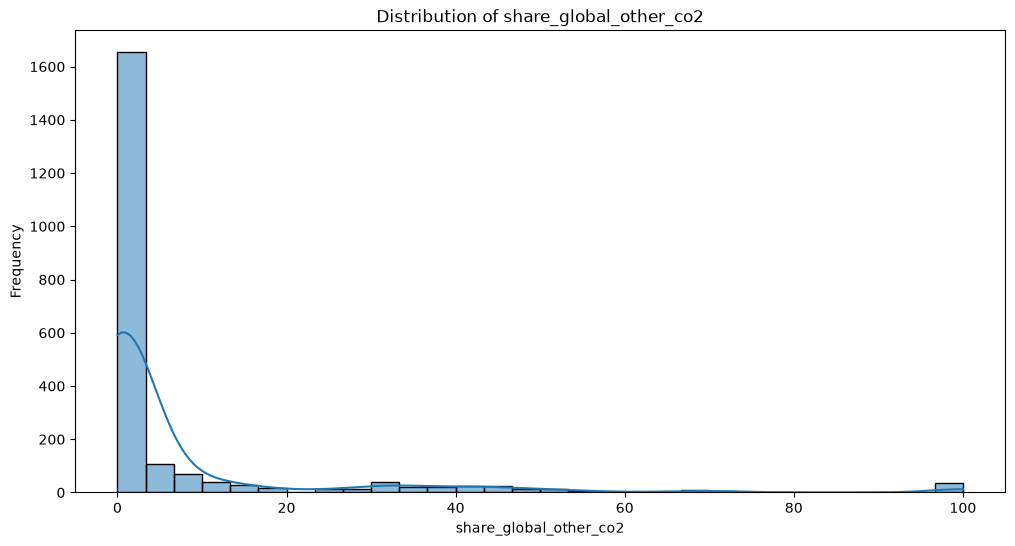

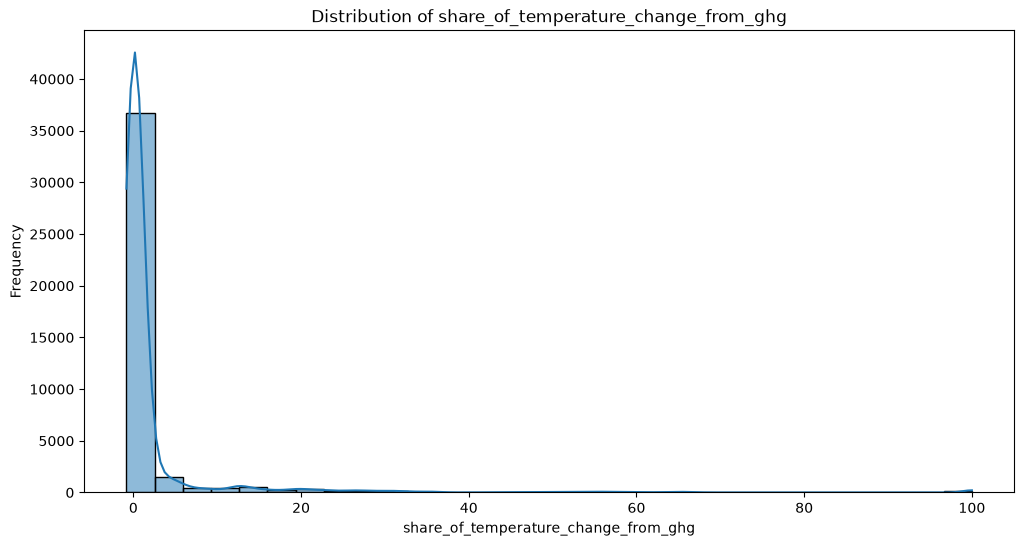

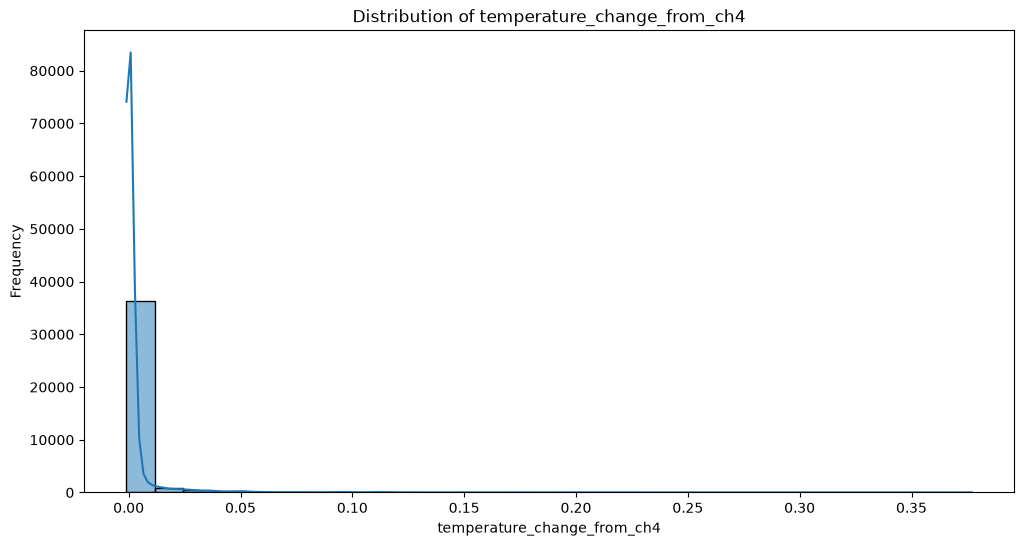

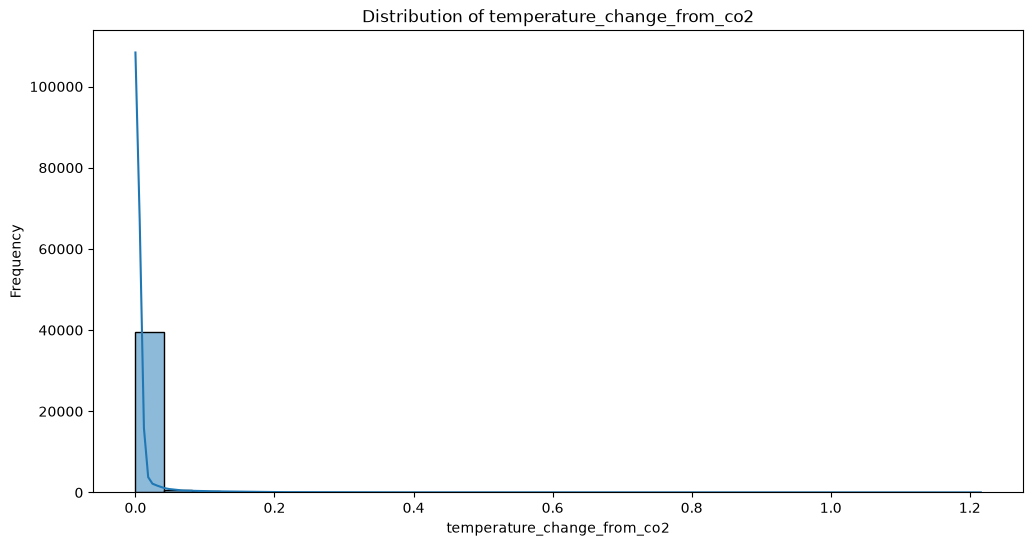

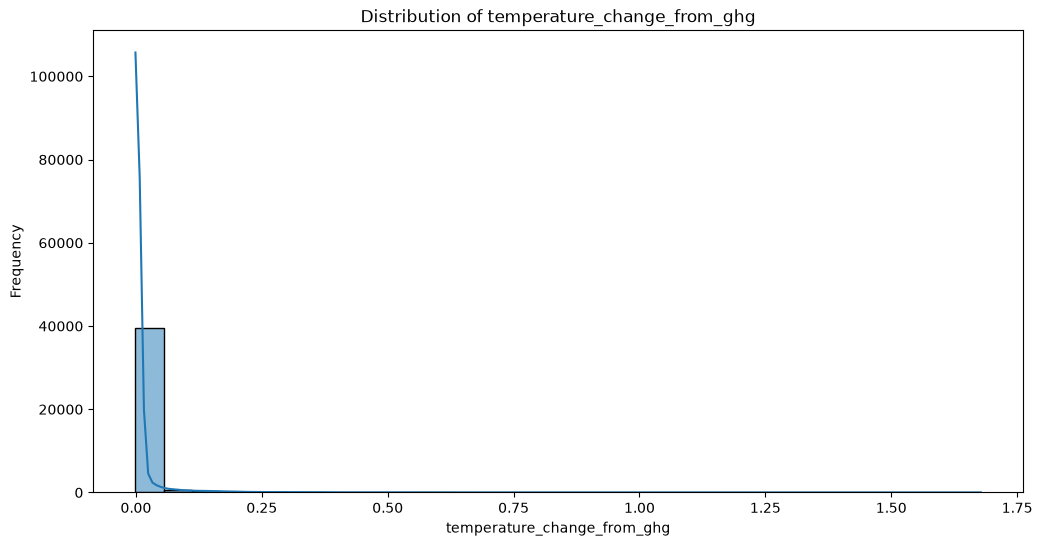

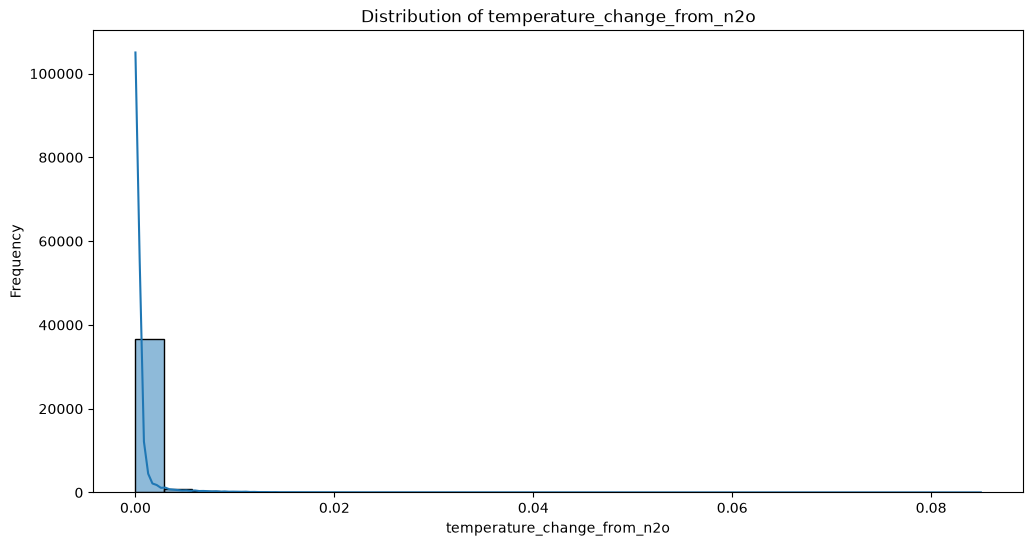

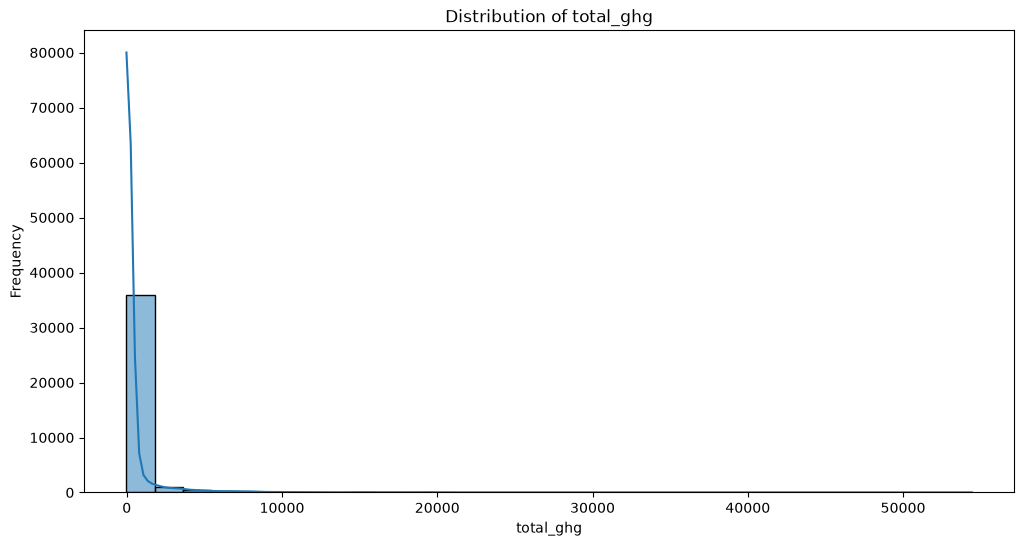

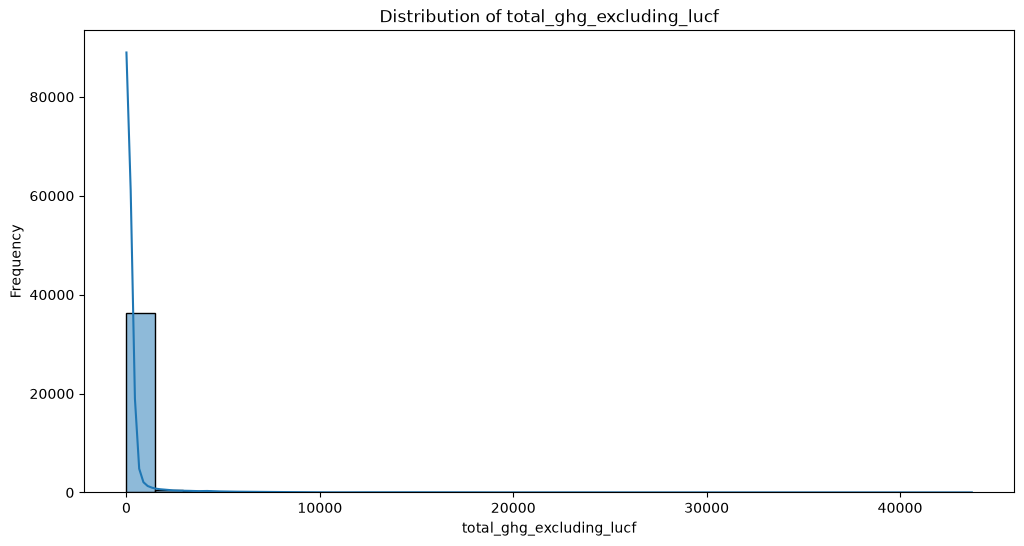

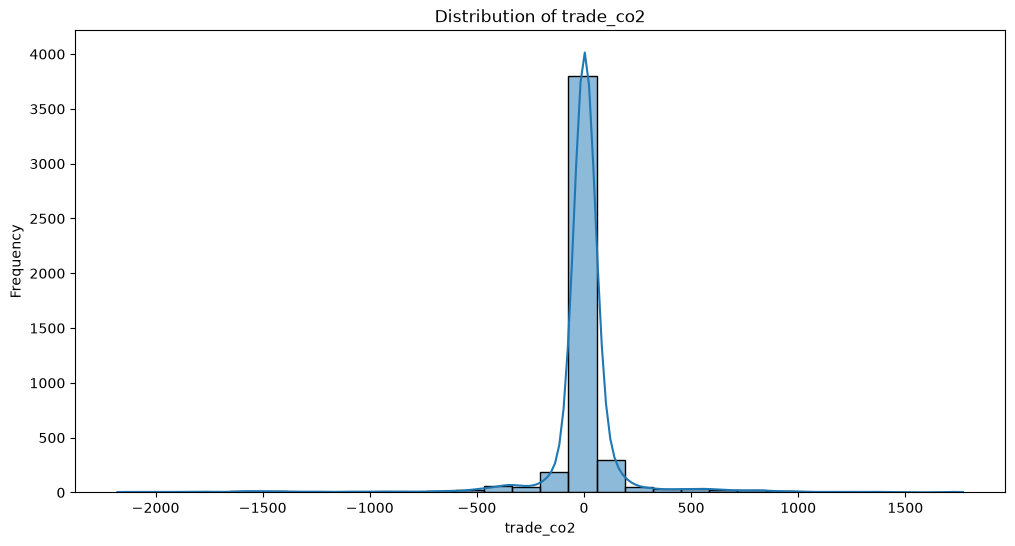

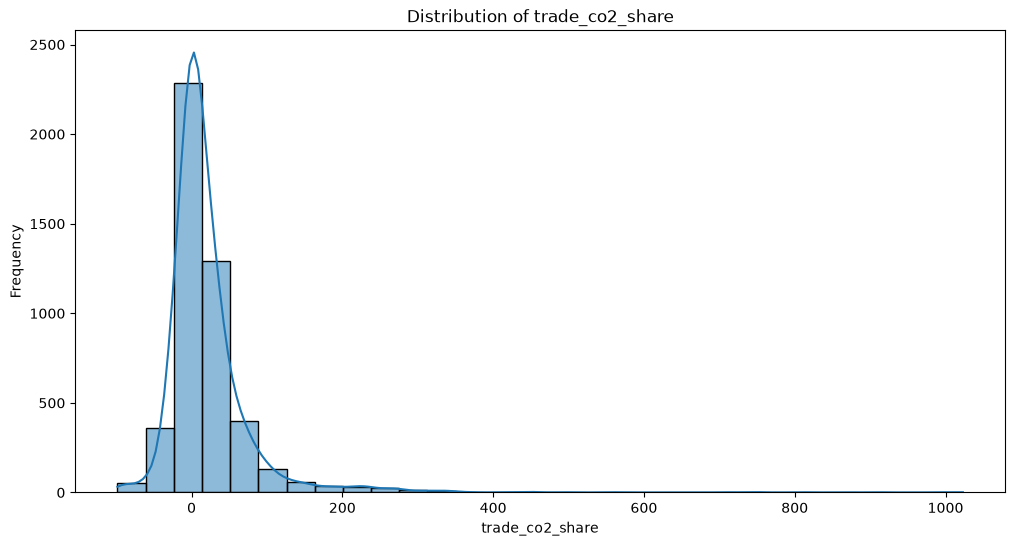

In [51]:
# plot the distribution of columns to show skewness and kurtosis
for column in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[column].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


The distribution of the dataset is skewed. Median imputation will be used where necessary.

In [52]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    89.213086
1751    91.931919
1752    91.931919
1753    91.931919
1754    91.931919
1755    91.931919
1756    91.931919
1757    91.931919
1758    91.931919
1759    91.931919
1760    88.770999
1761    91.931919
1762    91.931919
1763    91.931919
1764    91.931919
1765    91.931919
1766    91.931919
1767    91.931919
1768    91.931919
1769    91.931919
1770    88.770999
1771    91.931919
1772    91.931919
1773    91.931919
1774    91.931919
1775    91.931919
1776    91.931919
1777    91.931919
1778    91.931919
1779    91.931919
1780    88.770999
1781    91.931919
1782    91.931919
1783    91.931919
1784    91.931919
1785    91.242938
1786    91.112560
1787    91.112560
1788    91.112560
1789    91.112560
1790    87.722729
1791    91.112560
1792    90.705128
1793    90.619658
1794    90.619658
1795    90.619658
1796    90.619658
1797    90.619658
1798    90.619658
1799    90.619658
1800    86.579818
1801    86.579818
1802    86.237981
1803    86.579818
1804    86.406186
1805 

We will keep years from 1950 onwards as it crosses the threshold of missing values

## Data Preprocessing

### Steps in the data preprocessing pipeline
0. Ensure the data type of year is datetime
1. Keep years from 1950 onwards
2. Keep columns with 50% or less missing values
3. Impute missing numeric values using median
4. Define continents
5. Define income groups
6. Countries / territories
7. Continents
8. Income groups
9. Other aggregates

In [53]:
# Preprocessing pipeline
def preprocessing_pipeline(data):

    # Make a copy of the original dataset
    data = data.copy()
    
    # 0. Ensure the 'year' column is of datetime type
    data['year'] = pd.to_datetime(data['year'], format='%Y').dt.year
    display(data['year'].dtypes)

    # 1. Keep years from 1950 onwards
    data = data[data["year"] >= 1950].copy()

    # 2. Keep columns with 50% or less missing values
    data = data.loc[:, data.isnull().mean() <= 0.5].copy()# If a column has 70–95% missing values, filling the missing values would mean that most of the data is artificially created rather than observed.

    # 3. Impute missing numeric values using median
    numeric_columns = data.select_dtypes(include="number").columns

    for col in numeric_columns:
        data[col] = data[col].fillna(data[col].median())# The median is appropriate for this emissions dataset because many emissions variables are highly skewed and contain extreme values.

    # 4. Define continents
    continents = [
        "Africa",
        "Asia",
        "Europe",
        "North America",
        "South America",
        "Oceania"
    ]

    # 5. Define income groups
    income_groups = [
        "High-income countries",
        "Upper-middle-income countries",
        "Lower-middle-income countries",
        "Low-income countries",
        'Least developed countries (Jones et al.)'
    ]
    # 6. Countries / territories
    data_countries = data[
        data["iso_code"].notna()
    ].copy()#This allows you to separate countries/territories from aggregate entities.

    # 7. Continents
    data_continents = data[
        data["country"].isin(continents)
    ].copy()

    # 8. Income groups
    data_income_groups = data[
        data["country"].isin(income_groups)
    ].copy()

    # 9. Other aggregates
    data_region_group_entities= data[
        data["iso_code"].isna()
        & ~data["country"].isin(continents)
        & ~data["country"].isin(income_groups)
    ].copy()

    # Return all datasets
    return (
        data,
        data_countries,
        data_continents,
        data_income_groups,
        data_region_group_entities
    )


df_cleaned, df_countries, df_continents, df_income_groups, df_region_group_entities = preprocessing_pipeline(df)

dtype('int32')

Based on earlier analysis, we:

- Kept data from 1950 onwards

- Dropped columns with missing values exceeding the threshold 

- Used median imputation as the distribution is skewed

- We separated the dataset to categories from step 4 to step 9

In [54]:
print("Countries/Territories:",
      df_countries["country"].nunique())

print("Continents:",
      df_continents["country"].nunique())

print("Income Groups:",
      df_income_groups["country"].nunique())

print("Other Aggregates:",
      df_region_group_entities["country"].nunique())

Countries/Territories: 218
Continents: 6
Income Groups: 5
Other Aggregates: 25


Unique values in the country column: 
* 218 Countries/Territories: 
* 6 Continents
* 4 Income Groups
* 26 region/group entities

In [55]:
df_countries["country"].unique()

<ArrowStringArray>
[        'Afghanistan',             'Albania',             'Algeria',
             'Andorra',              'Angola',            'Anguilla',
          'Antarctica', 'Antigua and Barbuda',           'Argentina',
             'Armenia',
 ...
             'Uruguay',          'Uzbekistan',             'Vanuatu',
             'Vatican',           'Venezuela',             'Vietnam',
   'Wallis and Futuna',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 218, dtype: str

In [56]:
df_region_group_entities['country'].unique()

<ArrowStringArray>
[                'Africa (GCP)',                   'Asia (GCP)',
 'Asia (excl. China and India)',        'Central America (GCP)',
                 'Europe (GCP)',         'Europe (excl. EU-27)',
         'Europe (excl. EU-28)',          'European Union (27)',
          'European Union (28)',       'International aviation',
       'International shipping',                       'Kosovo',
            'Kuwaiti Oil Fires',      'Kuwaiti Oil Fires (GCP)',
            'Middle East (GCP)',               'Non-OECD (GCP)',
          'North America (GCP)',    'North America (excl. USA)',
                   'OECD (GCP)',          'OECD (Jones et al.)',
                'Oceania (GCP)',               'Ryukyu Islands',
         'Ryukyu Islands (GCP)',          'South America (GCP)',
                        'World']
Length: 25, dtype: str

In [57]:
cleaned_cols = df_cleaned.columns

# check cleaned_cols against original df columns
original_cols = df.columns
# check for any columns that are in the original df but not in the cleaned df
missing_cols = [col for col in original_cols if col not in cleaned_cols]
print(missing_cols)

['consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_gas_co2', 'cumulative_other_co2', 'energy_per_gdp', 'gas_co2', 'gas_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_other_co2', 'share_global_gas_co2', 'share_global_other_co2', 'trade_co2', 'trade_co2_share']


These columns were removed due to exceeding the missing value threshold.

## Get the value counts for each column with normalize true to have it in percentile.

In [58]:
# Get percentage value counts for each column
for column in df_cleaned.columns:
    print(
        df_cleaned[column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .head(10)
    )

country
Afghanistan            0.4
Africa                 0.4
Africa (GCP)           0.4
Albania                0.4
Algeria                0.4
Andorra                0.4
Angola                 0.4
Anguilla               0.4
Antarctica             0.4
Antigua and Barbuda    0.4
Name: proportion, dtype: float64
year
1994    1.34
1995    1.34
1996    1.34
1997    1.34
1998    1.34
1999    1.34
2000    1.34
2001    1.34
2002    1.34
2003    1.34
Name: proportion, dtype: float64
iso_code
NaN    13.87
AFG     0.40
ALB     0.40
DZA     0.40
AND     0.40
AGO     0.40
AIA     0.40
ATA     0.40
ATG     0.40
ARG     0.40
Name: proportion, dtype: float64
population
4466330.0    9.53
5674.0       0.02
737.0        0.02
5346.0       0.01
29457.0      0.01
64631.0      0.01
5802.0       0.01
5899.0       0.01
6427.0       0.01
6466.0       0.01
Name: proportion, dtype: float64
gdp
3.224005e+10    39.57
6.325920e+08     0.01
7.632000e+07     0.01
9.421400e+09     0.01
9.692280e+09     0.01
1.001732e+1

Country: Each listed country/entity represents about 0.40% of the observations. The dataset includes both countries and regional aggregates such as Africa.
Year: Each year represents approximately 1.34%, indicating a relatively even distribution across years.
ISO Code: 13.87% of ISO codes are missing, likely because some records represent regions or aggregate entities.
Population: The most frequent population value accounts for 9.53%, showing considerable variation in population sizes.
GDP: One GDP value accounts for 39.57% of observations, indicating a high concentration that should be investigated.
Cement CO₂: 27.96% of observations have zero cement CO₂ emissions, while 13.85% have a value of 0.228.
CO₂: The most frequent CO₂ value accounts for 7.58%, indicating substantial variation in emissions.
CO₂ growth: The most common absolute growth value represents 12.52%, while the most common percentage growth represents 12.82%.
Energy: primary_energy_consumption has 44.01% of observations at the same value, while energy_per_capita has 44.24%, suggesting repeated or aggregate values that require investigation.
Coal CO₂: 37.03% of observations share the same coal CO₂ value, while 8.19% have zero emissions.
Flaring CO₂: 41.30% have a value of 0.002 and 29.26% have zero, showing that flaring emissions are generally very low.
Overall: The dataset contains skewed emissions distributions, 13.87% missing ISO codes, and several variables with high repeated-value proportions (around 37–47%). These patterns should be checked for regional aggregates, duplicated records, or data-processing issues before modelling.

In [59]:
for column in df_cleaned.columns:
    print(f"\nValue counts for {column}:")
    print(df[column].value_counts(normalize=True, dropna=False).head(10) * 100)


Value counts for country:
country
Afghanistan                     0.545516
Africa                          0.545516
Andorra                         0.545516
Antarctica                      0.545516
Asia                            0.545516
Asia (excl. China and India)    0.545516
Australia                       0.545516
Bahrain                         0.545516
Bangladesh                      0.545516
Barbados                        0.545516
Name: proportion, dtype: float64

Value counts for year:
year
1994    0.503858
1995    0.503858
1996    0.503858
1997    0.503858
1998    0.503858
1999    0.503858
2000    0.503858
2001    0.503858
2002    0.503858
2003    0.503858
Name: proportion, dtype: float64

Value counts for iso_code:
iso_code
NaN    15.732677
AFG     0.545516
AND     0.545516
ATA     0.545516
AUS     0.545516
BHR     0.545516
BGD     0.545516
BRB     0.545516
BTN     0.545516
BOL     0.545516
Name: proportion, dtype: float64

Value counts for population:
population
NaN      

co2_including_luc_growth_abs
 NaN      53.391125
-0.000     0.482038
 0.004     0.245978
 0.007     0.140842
-0.004     0.138859
 0.002     0.109103
 0.005     0.093234
 0.003     0.089266
 0.001     0.087283
 0.008     0.087283
Name: proportion, dtype: float64

Value counts for co2_including_luc_growth_prct:
co2_including_luc_growth_prct
 NaN        53.391125
-0.000       0.392771
 100.000     0.017853
 0.686       0.013886
-0.473       0.013886
 33.333      0.013886
 14.286      0.013886
 1.389       0.013886
 50.000      0.013886
 3.860       0.011902
Name: proportion, dtype: float64

Value counts for co2_including_luc_per_capita:
co2_including_luc_per_capita
NaN      52.873381
0.769     0.025788
2.023     0.019837
0.728     0.019837
2.767     0.017853
1.595     0.017853
1.025     0.017853
0.667     0.017853
2.035     0.017853
2.123     0.017853
Name: proportion, dtype: float64

Value counts for co2_including_luc_per_gdp:
co2_including_luc_per_gdp
NaN      66.693777
0.284     0.0515

Column analysis of the cleaned dataset.

In [60]:
# Put all your DataFrames in a dictionary
datasets = {
    "Continent": df_continents,
    "Income Groups": df_income_groups,
    "Region Group ": df_region_group_entities,
    "Countries": df_countries

}  

# Loop through each dataset and each column
for name, df in datasets.items():
    print(f"\n===== Value Counts for {name} Dataset =====")
    for col in df.columns:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts(normalize=True, dropna=False).head(10) * 100)



===== Value Counts for Continent Dataset =====

Value counts for country:
country
Africa           16.666667
Asia             16.666667
Europe           16.666667
North America    16.666667
Oceania          16.666667
South America    16.666667
Name: proportion, dtype: float64

Value counts for year:
year
1950    1.333333
1951    1.333333
1952    1.333333
1953    1.333333
1954    1.333333
1955    1.333333
1956    1.333333
1957    1.333333
1958    1.333333
1959    1.333333
Name: proportion, dtype: float64

Value counts for iso_code:
iso_code
NaN    100.0
Name: proportion, dtype: float64

Value counts for population:
population
227776838.0    0.222222
232557370.0    0.222222
237539910.0    0.222222
242685417.0    0.222222
248006203.0    0.222222
253538234.0    0.222222
259271764.0    0.222222
265129059.0    0.222222
271042090.0    0.222222
277271946.0    0.222222
Name: proportion, dtype: float64

Value counts for gdp:
gdp
3.224005e+10    100.0
Name: proportion, dtype: float64

Value coun

In [62]:
# --- 2) Classification-style EDA using CO2 classes ---

# Build a country-level latest-year modeling frame
class_base_cols = ['country', 'year', 'co2', 'co2_per_capita']
model_cols = sorted(set(class_base_cols + sum(existing_group_cols.values(), [])))
model_cols = [c for c in model_cols if c in latest.columns]

latest_model = latest[model_cols].copy()
latest_model = latest_model[latest_model['co2_per_capita'].notna()].copy()

# Create emission class labels from quartiles of CO2 per capita
latest_model['emission_class'] = pd.qcut(
    latest_model['co2_per_capita'],
    q=4,
    labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'],
    duplicates='drop'
)

# Compare each group by emission class
class_summary_parts = []
for group_name, cols in existing_group_cols.items():
    valid_cols = [c for c in cols if c in latest_model.columns]
    if not valid_cols:
        continue
    grouped = latest_model.groupby('emission_class')[valid_cols].median(numeric_only=True)
    grouped = grouped.T
    grouped['group'] = group_name
    grouped['range_across_classes'] = grouped.max(axis=1, numeric_only=True) - grouped.min(axis=1, numeric_only=True)
    class_summary_parts.append(grouped.reset_index().rename(columns={'index': 'column'}))

class_summary = pd.concat(class_summary_parts, ignore_index=True)
class_summary = class_summary.sort_values(['group', 'range_across_classes'], ascending=[True, False])

print('Columns with strongest class separation in each sub-dataset (median spread across CO2 classes):')
display(class_summary.groupby('group').head(6).reset_index(drop=True))

# Visual comparison: class-wise medians, normalized for readability
class_medians = latest_model.groupby('emission_class')[[c for c in numeric_cols if c in latest_model.columns]].median(numeric_only=True)
class_norm = (class_medians - class_medians.mean()) / class_medians.std(ddof=0)

plt.figure(figsize=(14, 8))
sns.heatmap(class_norm.T, cmap='RdBu_r', center=0)
plt.title('Normalized Median Feature Values by CO2 Emission Class (Latest Year)')
plt.xlabel('Emission Class')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

NameError: name 'existing_group_cols' is not defined

Column analysis of each sub-dataset(Continent, Income Groups, Region Group, Countries)

In [61]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import shap


# ============================================================
# STEP 1: SELECT ONE OF THE FIVE TABLES
# ============================================================

print("Select the dataset you want to use:")
print("1 - df_cleaned")
print("2 - df_countries")
print("3 - df_continents")
print("4 - df_income_groups")
print("5 - df_region_group_entities")

selection = int(input("\nEnter your choice (1-5): "))


# Map number to DataFrame
datasets = {
    1: ("df_cleaned", df_cleaned),
    2: ("df_countries", df_countries),
    3: ("df_continents", df_continents),
    4: ("df_income_groups", df_income_groups),
    5: ("df_region_group_entities", df_region_group_entities)
}


# Check selection
if selection not in datasets:
    raise ValueError("Invalid choice. Please enter a number from 1 to 5.")


table_name, selected_df = datasets[selection]

print("\nSelected table:", table_name)
print("Shape:", selected_df.shape)


# ============================================================
# STEP 2: MAKE A COPY
# ============================================================

df_model = selected_df.copy()


# ============================================================
# STEP 3: CHECK THAT CO2 EXISTS
# ============================================================

if "co2" not in df_model.columns:
    raise ValueError(
        f"\n'{table_name}' does not contain a 'co2' column. "
        "Choose a table containing CO2 data."
    )


# ============================================================
# STEP 4: REMOVE MISSING CO2 VALUES
# ============================================================

df_model = df_model[
    df_model["co2"].notna()
].copy()

print("Rows after removing missing CO2:", len(df_model))


# ============================================================
# STEP 5: CREATE LOW / MEDIUM / HIGH EMISSION CLASSES
# ============================================================

df_model["emission_class"] = pd.qcut(
    df_model["co2"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)


# Check target distribution
print("\nEmission class distribution:")
print(df_model["emission_class"].value_counts())


# ============================================================
# STEP 6: REMOVE CO2 LEAKAGE VARIABLES
# ============================================================

leakage_cols = [
    col for col in df_model.columns
    if "co2" in col.lower()
]

print("\nCO2 leakage columns removed:")
print(leakage_cols)


feature_cols = [
    col for col in df_model.columns
    if col not in leakage_cols + ["emission_class"]
]


# ============================================================
# STEP 7: CREATE X AND Y
# ============================================================

X = df_model[feature_cols]
y = df_model["emission_class"]


print("\nNumber of predictor variables:", len(feature_cols))


# ============================================================
# STEP 8: IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number"]
).columns.tolist()


print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


# ============================================================
# STEP 9: PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median"))
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent")
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)


# ============================================================
# STEP 10: RANDOM FOREST MODEL
# ============================================================

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)


# ============================================================
# STEP 11: TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


# ============================================================
# STEP 12: TRAIN MODEL
# ============================================================

print("\nTraining Random Forest...")

clf.fit(X_train, y_train)


# ============================================================
# STEP 13: PREDICTIONS
# ============================================================

y_pred = clf.predict(X_test)


# ============================================================
# STEP 14: MODEL EVALUATION
# ============================================================

print("\n====================================")
print("MODEL EVALUATION")
print("====================================")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred), 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# STEP 15: PREPARE DATA FOR SHAP
# ============================================================

preprocessor_fitted = clf.named_steps["preprocessor"]
rf_model = clf.named_steps["model"]


# Use up to 1,000 observations for faster SHAP calculation
X_test_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)


X_test_transformed = preprocessor_fitted.transform(
    X_test_sample
)


# Convert sparse matrix to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


# Get transformed feature names
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)


# ============================================================
# STEP 16: SHAP EXPLAINER
# ============================================================

print("\nCalculating SHAP values...")

explainer = shap.TreeExplainer(rf_model)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values = explainer.shap_values(
        X_test_transformed
    )


# ============================================================
# STEP 17: CALCULATE SHAP IMPORTANCE
# ============================================================

if isinstance(shap_values, list):

    shap_importance = np.mean(
        [
            np.abs(class_values).mean(axis=0)
            for class_values in shap_values
        ],
        axis=0,
    )

elif (
    isinstance(shap_values, np.ndarray)
    and shap_values.ndim == 3
):

    shap_importance = np.abs(
        shap_values
    ).mean(axis=(0, 2))

else:

    shap_importance = np.abs(
        shap_values
    ).mean(axis=0)


# ============================================================
# STEP 18: CREATE SHAP IMPORTANCE TABLE
# ============================================================

shap_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap": shap_importance,
    }
).sort_values(
    "mean_abs_shap",
    ascending=False
)


print("\n====================================")
print("TOP 20 SHAP IMPORTANT FEATURES")
print("====================================")

display(
    shap_importance_df.head(20)
)


# ============================================================
# STEP 19: SHAP BAR CHART
# ============================================================

plt.figure(figsize=(10, 8))

sns.barplot(
    data=shap_importance_df.head(20),
    x="mean_abs_shap",
    y="feature",
    palette="magma"
)

plt.title(
    f"Top 20 Feature Importances - {table_name}"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.tight_layout()

plt.show()


# ============================================================
# STEP 20: SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

Select the dataset you want to use:
1 - df_cleaned
2 - df_countries
3 - df_continents
4 - df_income_groups
5 - df_region_group_entities


ValueError: invalid literal for int() with base 10: 'usa'

## Feature importance

Classification

Accuracy: 0.9817

Classification report:

              precision    recall  f1-score   support

        High       0.99      0.99      0.99      1090
         Low       0.98      0.98      0.98      1091
      Medium       0.97      0.98      0.97      1089

    accuracy                           0.98      3270
   macro avg       0.98      0.98      0.98      3270
weighted avg       0.98      0.98      0.98      3270


Top 20 SHAP important features:



,feature,mean_abs_shap
16,num__total_ghg_excluding_lucf,0.093609
10,num__primary_energy_consumption,0.051330
4,num__ghg_excluding_lucf_per_capita,0.039445
2,num__gdp,0.033583
15,num__total_ghg,0.031706
1,num__population,0.027834
11,num__share_of_temperature_change_from_ghg,0.027325
6,num__methane,0.021072
13,num__temperature_change_from_ghg,0.020592
8,num__nitrous_oxide,0.018194


C:\Users\User\AppData\Local\Temp\ipykernel_6440\2778336987.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


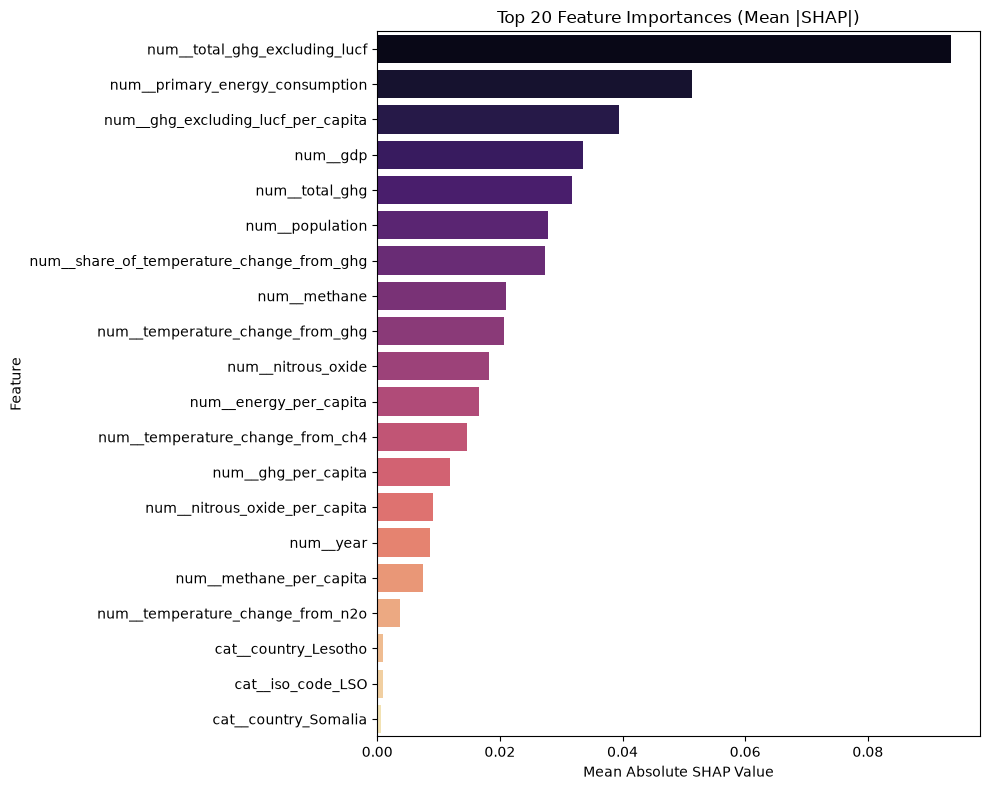

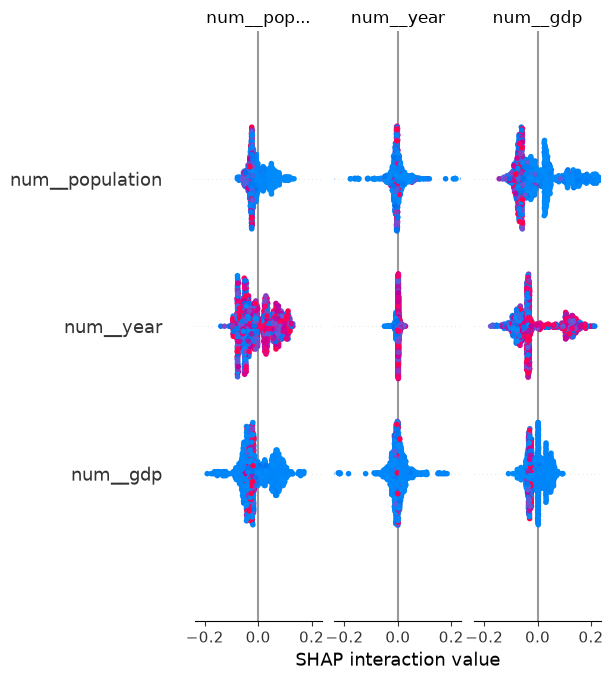

In [ ]:
import warnings
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import shap

# Build a classification target from CO2 emission quantiles.
df_countries2 = df_countries.copy()
df_countries2 = df_countries2[df_countries2["co2"].notna()].copy()

# Tertile-based classes: Low, Medium, High emitters.
df_countries2["emission_class"] = pd.qcut(
    df_countries2["co2"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# Remove direct leakage variables containing "co2" from predictors.
leakage_cols = [col for col in df_countries2.columns if "co2" in col.lower()]
feature_cols = [
    col for col in df_countries2.columns
    if col not in leakage_cols + ["emission_class"]
]

X = df_countries2[feature_cols]
y = df_countries2["emission_class"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# SHAP on transformed features from the fitted preprocessing pipeline.
preprocessor_fitted = clf.named_steps["preprocessor"]
rf_model = clf.named_steps["model"]

# Use a sample for faster SHAP computation.
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
X_test_transformed = preprocessor_fitted.transform(X_test_sample)

# Convert sparse matrix to dense for SHAP compatibility when needed.
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor_fitted.get_feature_names_out()
explainer = shap.TreeExplainer(rf_model)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values = explainer.shap_values(X_test_transformed)

# Aggregate absolute SHAP values across classes and samples.
if isinstance(shap_values, list):
    shap_importance = np.mean(
        [np.abs(class_values).mean(axis=0) for class_values in shap_values],
        axis=0,
    )
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_importance = np.abs(shap_values).mean(axis=(0, 2))
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap": shap_importance,
    }
).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 SHAP important features:\n")
display(shap_importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importance_df.head(20),
    x="mean_abs_shap",
    y="feature",
    palette="magma"
)
plt.title("Top 20 Feature Importances (Mean |SHAP|)")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

# Optional SHAP summary plot on the same sample.
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

# EDA

In [ ]:
df_countries.shape

(16350, 63)

In [ ]:
# Basic overview of the country-level dataset

print("Dataset Shape:", df_countries.shape)

print(
    "Number of Countries:",
    df_countries["country"].nunique()
)

print(
    "Year Range:",
    df_countries["year"].min(),
    "-",
    df_countries["year"].max()
)

df_countries.head()

Dataset Shape: (16350, 63)
Number of Countries: 218
Year Range: 1950 - 2024


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
200,Afghanistan,1950,AFG,7776180.0,9.421400e+09,0.0,0.0,0.084,0.070,475.000,7.169,1.052,17.202,0.922,0.761,282.23,0.011,0.009,220.8685,0.021,0.003,0.0,0.099,13.286,0.036,0.348,506.616,0.063,11792.955,0.002,0.001,0.159,2.555,7.085,0.911,7.879,1.013,2.231,0.287,0.063,0.008,58.186,0.0,0.001,0.057,0.001,0.0,0.0,0.002,0.0,0.004,0.116,0.000,0.001,0.106,0.004,0.131,0.0,0.0,0.001,0.0,19.869,1.236
201,Afghanistan,1951,AFG,7879343.0,9.692280e+09,0.0,0.0,0.092,0.007,8.696,8.092,0.923,12.875,1.027,0.835,282.23,0.012,0.009,220.8685,0.026,0.003,0.0,0.191,21.378,0.061,0.348,514.617,0.129,11792.955,0.002,0.001,0.154,2.674,8.000,1.015,7.973,1.012,2.292,0.291,0.066,0.008,58.186,0.0,0.001,0.060,0.001,0.0,0.0,0.003,0.0,0.004,0.116,0.000,0.001,0.111,0.004,0.130,0.0,0.0,0.001,0.0,21.069,1.217
202,Afghanistan,1952,AFG,7987784.0,1.001732e+10,0.0,0.0,0.092,0.000,0.000,9.005,0.913,11.287,1.127,0.899,282.23,0.011,0.009,220.8685,0.032,0.004,0.0,0.282,30.383,0.093,0.348,523.530,0.189,11792.955,0.002,0.001,0.149,2.766,8.914,1.116,8.073,1.011,2.365,0.296,0.060,0.007,58.186,0.0,0.001,0.066,0.001,0.0,0.0,0.004,0.0,0.004,0.116,0.001,0.001,0.123,0.003,0.130,0.0,0.0,0.001,0.0,22.094,1.189
203,Afghanistan,1953,AFG,8096703.0,1.063052e+10,0.0,0.0,0.106,0.015,16.000,10.070,1.065,11.823,1.244,0.947,282.23,0.013,0.010,220.8685,0.038,0.005,0.0,0.388,40.453,0.131,0.348,533.494,0.257,11792.955,0.002,0.001,0.146,2.872,9.964,1.231,8.186,1.011,2.447,0.302,0.068,0.008,58.186,0.0,0.002,0.072,0.001,0.0,0.0,0.006,0.0,0.004,0.117,0.001,0.001,0.135,0.004,0.130,0.0,0.0,0.001,0.0,23.256,1.180
204,Afghanistan,1954,AFG,8207954.0,1.086636e+10,0.0,0.0,0.106,0.000,0.000,10.928,0.858,8.517,1.331,1.006,282.23,0.013,0.010,220.8685,0.043,0.005,0.0,0.495,51.381,0.174,0.348,544.316,0.321,11792.955,0.002,0.001,0.141,2.955,10.821,1.318,8.305,1.012,2.532,0.309,0.064,0.008,58.186,0.0,0.002,0.075,0.001,0.0,0.0,0.007,0.0,0.004,0.117,0.001,0.001,0.139,0.003,0.130,0.0,0.0,0.001,0.0,24.251,1.155


#### Observation

The cleaned country-level dataset contains **16,627 observations and 63 variables**, representing **222 unique countries/entities** between **1950 and 2024**.

Each country has observations recorded across multiple years, making the dataset suitable for analyzing changes in CO₂ emissions over time. The dataset also contains multiple environmental, economic, demographic, and energy-related variables that can be explored for the classification analysis.

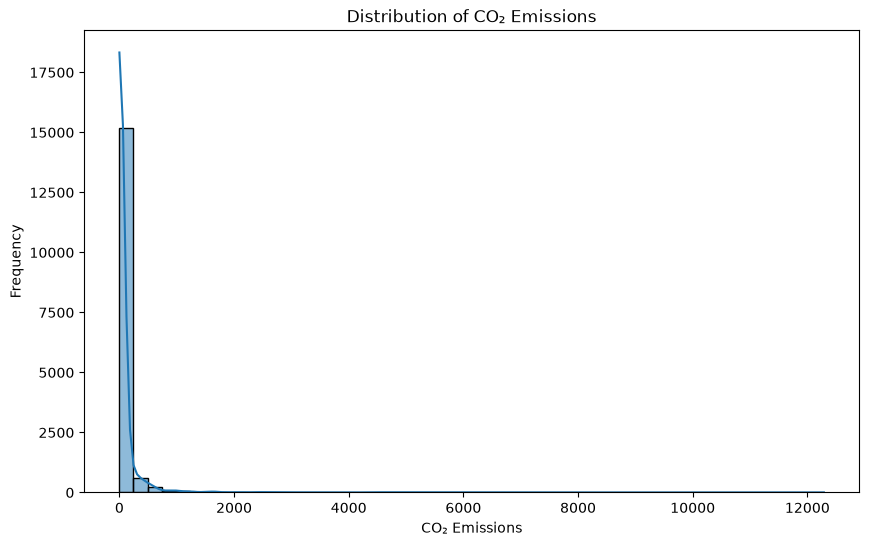

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_countries["co2"], bins=50, kde=True)
plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions")
plt.ylabel("Frequency")
plt.show()


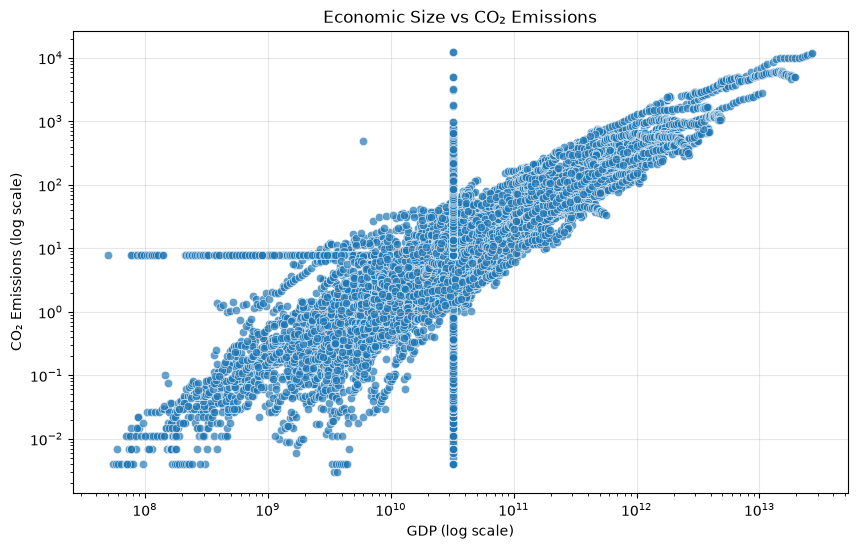

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_countries,
    x="gdp",
    y="co2",
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Economic Size vs CO₂ Emissions")
plt.xlabel("GDP (log scale)")
plt.ylabel("CO₂ Emissions (log scale)")
plt.grid(True, alpha=0.3)

plt.show()

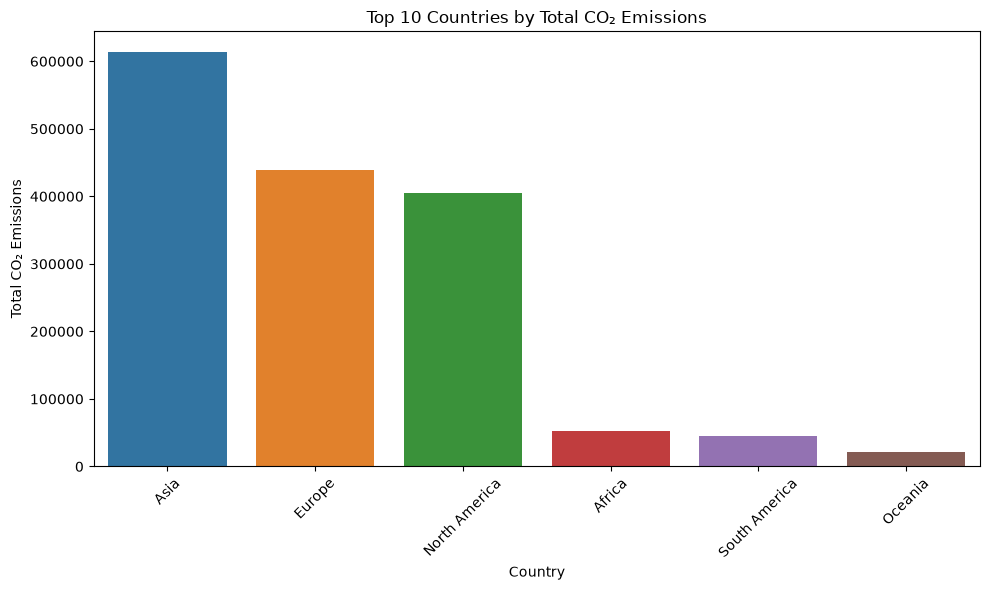

In [ ]:
top_emitters = df_continents.groupby("country")["co2"].sum().nlargest(6)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
country_avg = (
    df_countries
    .groupby("country", as_index=False)[["co2", "population"]]
    .mean()
)

country_avg["co2_per_capita"] = (
    country_avg["co2"] / country_avg["population"]
)

map_data = world.merge(
    country_avg,
    left_on="NAME",
    right_on="country",
    how="left"
)

fig, ax = plt.subplots(figsize=(15, 8))

map_data.plot(
    column="co2_per_capita",
    ax=ax,
    legend=True,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "Average CO₂ Emissions per Capita by Country",
    fontsize=16,
    fontweight="bold"
)

ax.axis("off")
plt.tight_layout()
plt.show()

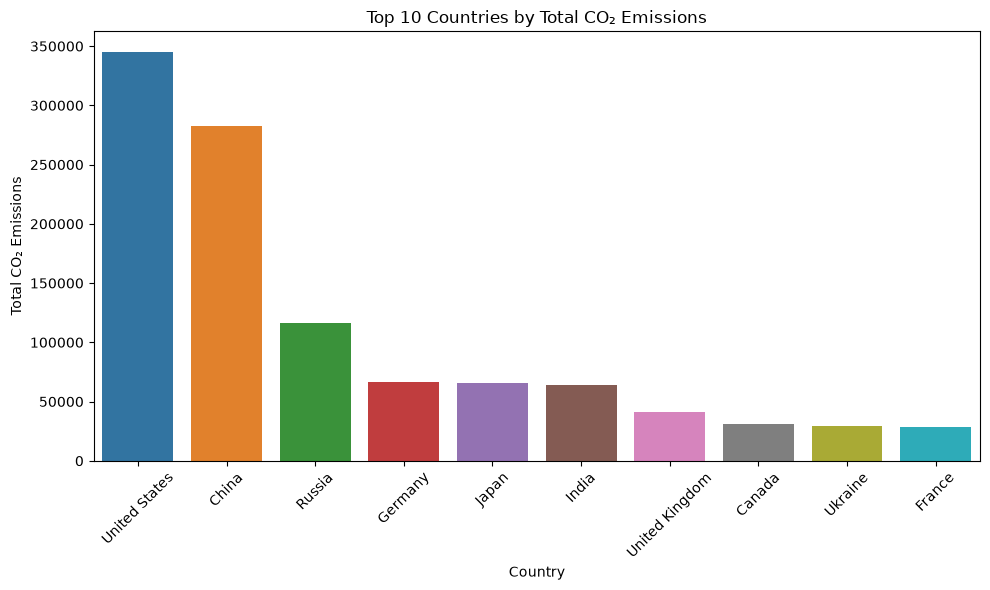

In [ ]:
top_emitters = df_countries.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

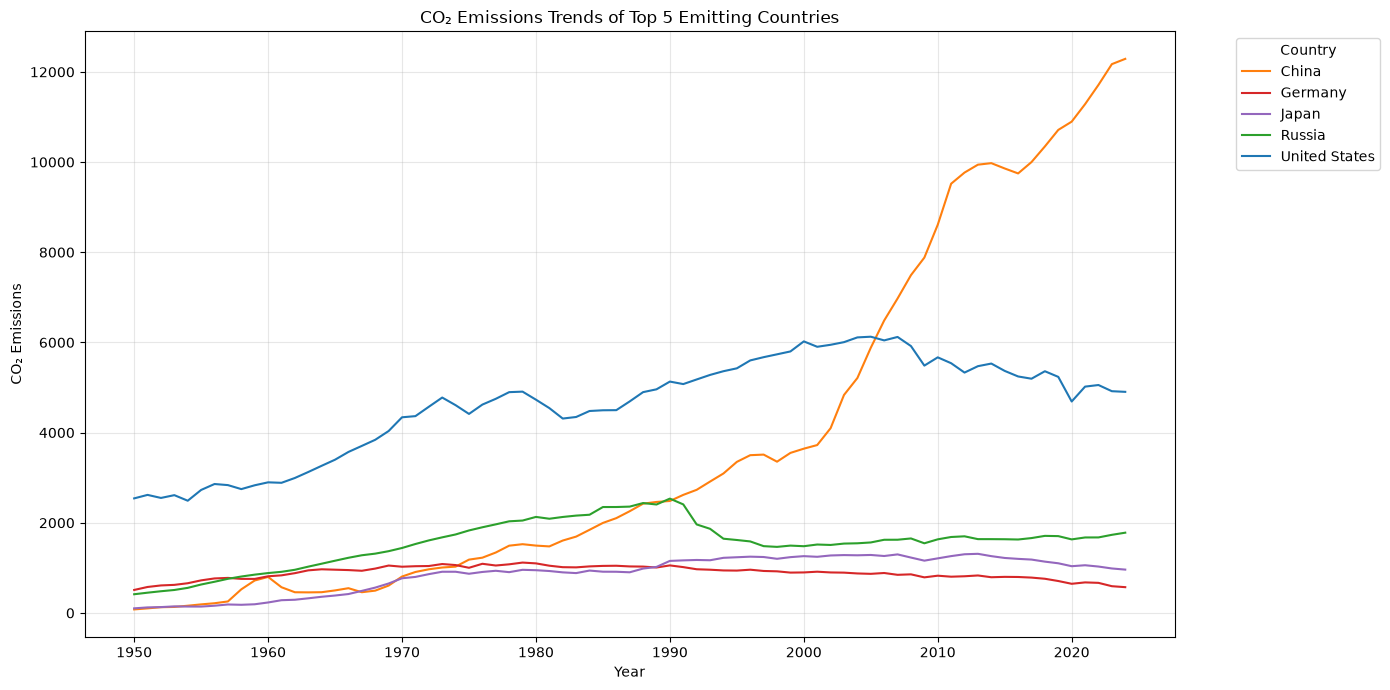

In [ ]:
# Identify the top 5 countries by total CO₂ emissions
top_5_countries = top_emitters.head(5).index

top_countries_df = df_countries[
    df_countries["country"].isin(top_5_countries)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=top_countries_df,
    x="year",
    y="co2",
    hue="country",
    palette={country: country_colors[country]
             for country in top_5_countries}
)

plt.title("CO₂ Emissions Trends of Top 5 Emitting Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_continents.shape

(450, 63)

In [ ]:
df_continents.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
475,Africa,1950,NaN,227776838.0,3.224005e+10,2.014,0.009,94.751,17.427,22.538,1750.405,956.900,120.591,7.694,5.690,282.23,0.416,0.308,220.8685,68.866,0.303,18.212,1737.787,15743.441,1633.885,0.0,47389.531,84.347,11792.955,0.0,0.0,0.929,7.718,1671.554,7.348,263.896,1.159,213.890,0.939,23.867,0.105,58.186,3.011,1.598,13.909,1.775,1.696,0.749,2.377,0.826,0.0,10.894,0.302,0.0,25.121,1.538,5.745,0.006,0.016,0.024,0.002,1758.008,211.710
476,Africa,1951,NaN,232557370.0,3.224005e+10,2.269,0.010,101.052,6.301,6.650,1798.121,47.715,2.726,7.742,5.585,282.23,0.435,0.314,220.8685,72.676,0.313,20.481,1838.839,17541.562,1706.561,0.0,49106.562,110.451,11792.955,0.0,0.0,0.958,7.794,1717.031,7.393,273.667,1.177,212.619,0.914,26.104,0.112,58.186,2.995,1.583,13.242,1.779,1.781,0.772,2.595,0.845,0.0,11.105,0.373,0.0,23.856,1.518,5.849,0.006,0.016,0.025,0.002,1812.640,222.898
477,Africa,1952,NaN,237539910.0,3.224005e+10,2.327,0.010,110.274,9.222,9.126,1856.187,58.067,3.229,7.824,5.556,282.23,0.465,0.330,220.8685,79.331,0.334,22.808,1949.113,19397.748,1785.892,0.0,50872.594,139.059,11792.955,0.0,0.0,0.981,7.749,1766.028,7.444,279.691,1.177,207.596,0.874,28.608,0.121,58.186,2.882,1.705,13.530,1.968,1.854,0.796,2.813,0.867,0.0,11.319,0.442,0.0,24.355,1.573,5.951,0.007,0.017,0.026,0.002,1840.792,233.045
478,Africa,1953,NaN,242685417.0,3.224005e+10,2.637,0.011,111.985,1.711,1.552,1922.408,66.221,3.568,7.932,5.552,282.23,0.462,0.323,220.8685,79.031,0.326,25.445,2061.098,21320.156,1864.923,0.0,52702.688,169.361,11792.955,0.0,0.0,1.001,7.760,1830.095,7.551,293.138,1.208,199.760,0.823,30.302,0.125,58.186,2.945,1.684,13.698,1.946,1.928,0.820,3.030,0.888,0.0,11.536,0.507,0.0,24.786,1.564,6.053,0.007,0.018,0.027,0.002,1883.315,242.888
479,Africa,1954,NaN,248006203.0,3.224005e+10,3.041,0.012,117.518,5.533,4.941,1995.504,73.095,3.802,8.057,5.500,282.23,0.474,0.324,220.8685,81.751,0.330,28.486,2178.615,23315.660,1946.674,0.0,54599.922,202.065,11792.955,0.0,0.0,1.021,7.822,1897.235,7.660,303.572,1.224,190.050,0.766,32.704,0.132,58.186,3.131,1.731,13.671,2.017,2.010,0.844,3.246,0.909,0.0,11.751,0.570,0.0,24.302,1.592,6.154,0.007,0.018,0.028,0.002,1939.954,253.321
480,Africa,1955,NaN,253538234.0,3.224005e+10,3.409,0.013,129.395,11.877,10.107,2088.945,93.442,4.683,8.250,5.571,282.23,0.511,0.345,220.8685,91.668,0.362,31.894,2308.010,25404.605,2038.342,0.0,56578.770,236.362,11792.955,0.0,0.0,1.067,7.945,1978.847,7.816,314.680,1.241,179.404,0.708,34.297,0.135,58.186,3.173,1.738,13.531,2.090,2.092,0.869,3.463,0.933,0.0,11.971,0.626,0.0,24.754,1.491,6.252,0.008,0.019,0.029,0.002,2014.385,270.545
481,Africa,1956,NaN,259271764.0,3.224005e+10,3.517,0.014

C:\Users\User\AppData\Local\Temp\ipykernel_6440\1376305336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_continents, x="country", y="co2", palette="Set2")


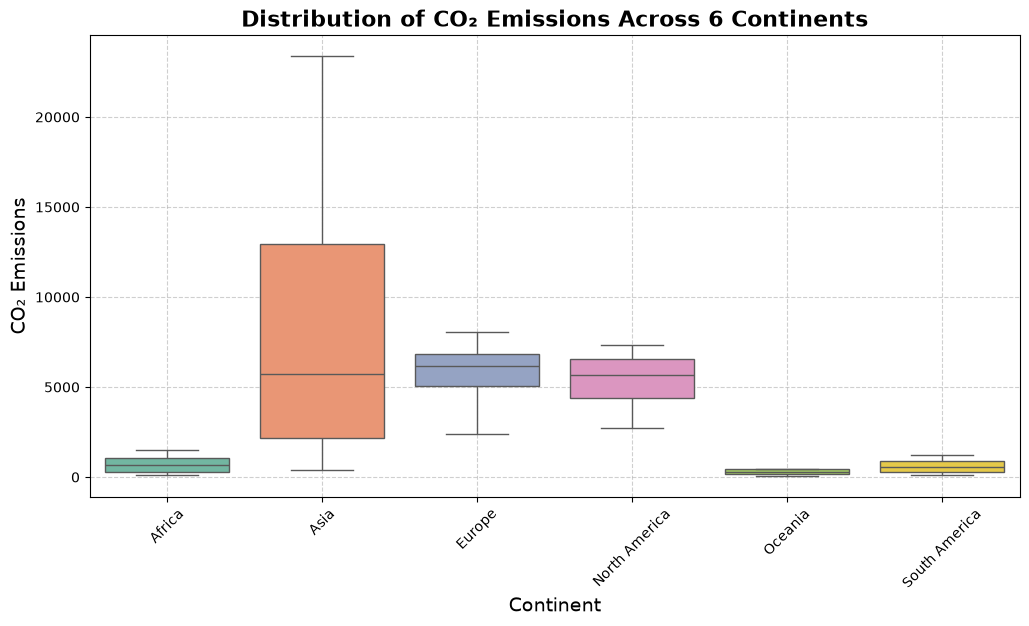

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_continents, x="country", y="co2", palette="Set2")
plt.title("Distribution of CO₂ Emissions Across 6 Continents", fontsize=16, fontweight="bold")
plt.xlabel("Continent", fontsize=14)
plt.ylabel("CO₂ Emissions", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

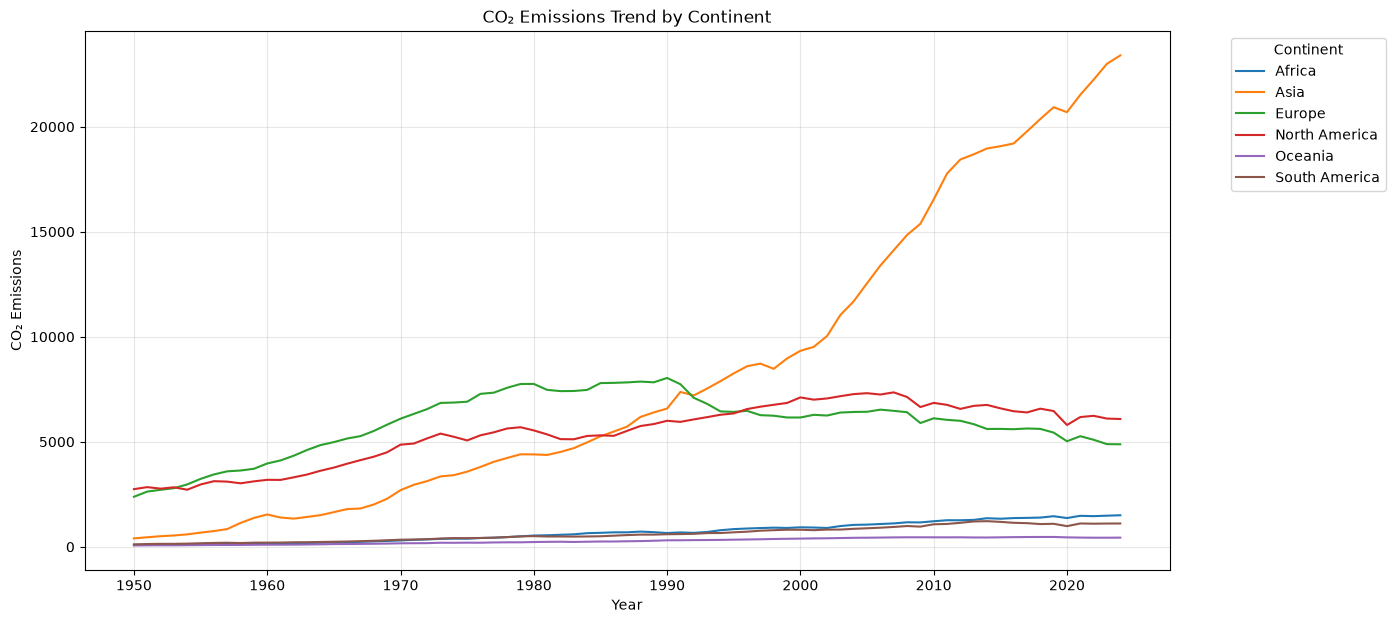

In [ ]:
# CO₂ emissions trend by continent

continent_trend = (
    df_continents
    .groupby(["year", "country"])["co2"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=continent_trend,
    x="year",
    y="co2",
    hue="country"
)

plt.title("CO₂ Emissions Trend by Continent")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True, alpha=0.3)
plt.show()

co2 emmissions over time

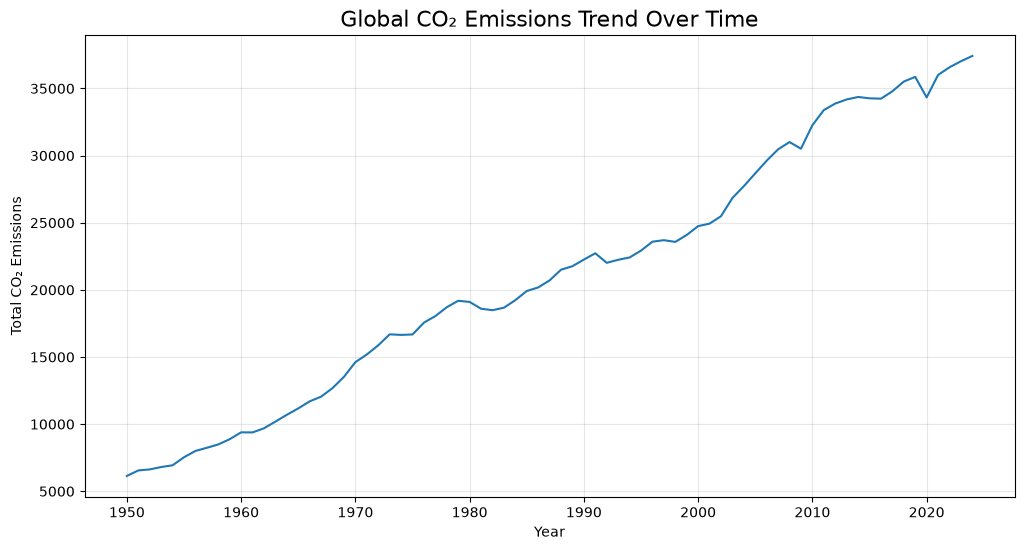

In [ ]:
# Trend analysis of CO₂ emissions over time

# Calculate total CO₂ emissions for each year
yearly_co2 = df_countries.groupby("year")["co2"].sum().reset_index()

# Plot the trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_co2,
    x="year",
    y="co2"
)

plt.title("Global CO₂ Emissions Trend Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total CO₂ Emissions")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Calculate year-on-year percentage change

yearly_co2["co2_growth"] = yearly_co2["co2"].pct_change() * 100

yearly_co2.tail()

,year,co2,co2_growth
70,2020,34334.126,-4.261769
71,2021,36002.866,4.860296
72,2022,36577.434,1.595895
73,2023,37026.972,1.229004
74,2024,37421.965,1.066771


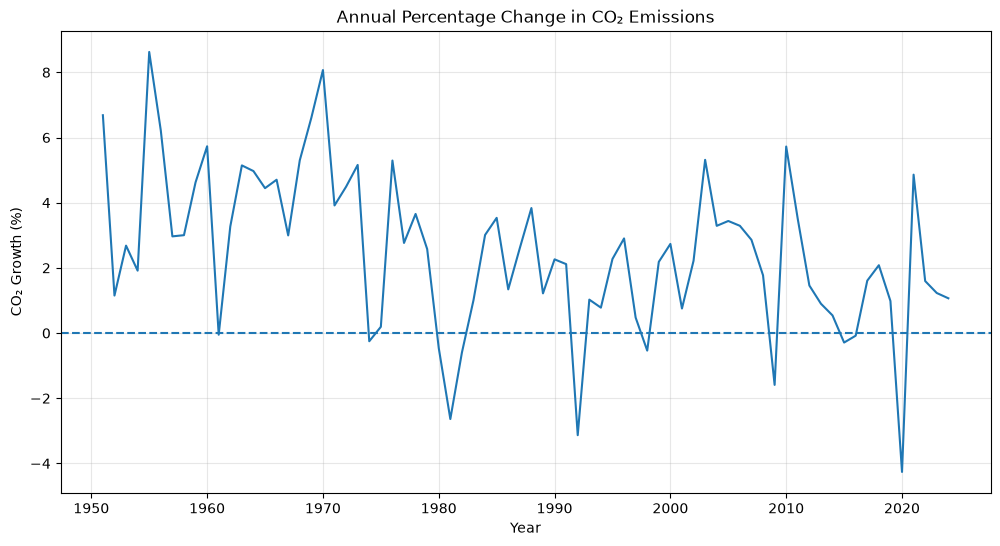

In [ ]:
# Plot annual CO₂ growth rate

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_co2,
    x="year",
    y="co2_growth"
)

plt.axhline(0, linestyle="--")

plt.title("Annual Percentage Change in CO₂ Emissions")
plt.xlabel("Year")
plt.ylabel("CO₂ Growth (%)")
plt.grid(True, alpha=0.3)

plt.show()

## Modeling

### Base Model

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Build modeling table from the country-level dataset.
if "df_countries" in globals():
    model_df = df_countries.copy()
elif "df" in globals():
    model_df = df[df["iso_code"].str.len() == 3].copy()
else:
    raise ValueError("No dataset found. Run the data loading and cleaning cells first.")

if "year" in model_df.columns:
    latest_year = int(model_df["year"].max())
    model_df = model_df[model_df["year"] == latest_year].copy()
    print(f"Using latest year snapshot for clustering: {latest_year}")

candidate_features = [
    "co2_per_capita",
    "co2_growth_prct",
    "gdp",
    "population",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_intensity",
    "carbon_intensity_elec",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "flaring_co2",
    "trade_co2",
    "methane",
    "nitrous_oxide",
    "renewables_share_energy",
    "fossil_share_energy",
]

available_features = [c for c in candidate_features if c in model_df.columns]
if len(available_features) < 5:
    raise ValueError(
        f"Not enough features found for clustering. Available: {available_features}"
    )

X = model_df[available_features].copy()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

X_prepared = preprocessor.fit_transform(X)

# Evaluate cluster counts and select k by silhouette score.
k_values = range(2, 9)
k_eval_rows = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_prepared)
    sil = silhouette_score(X_prepared, labels)
    k_eval_rows.append({
        "k": k,
        "silhouette": sil,
        "inertia": km.inertia_,
    })

k_eval_df = pd.DataFrame(k_eval_rows).sort_values("k")
display(k_eval_df)

best_k = int(k_eval_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Selected k = {best_k} (highest silhouette score).")

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
model_df["cluster"] = final_kmeans.fit_predict(X_prepared)

cluster_profile = (
    model_df.groupby("cluster")[available_features]
    .median()
    .round(3)
    .sort_index()
)
print("Cluster profile (median values):")
display(cluster_profile)

if "country" in model_df.columns:
    country_cluster_map = model_df[["country", "cluster"]].drop_duplicates().sort_values("country")
else:
    country_cluster_map = model_df[["cluster"]].copy()

print("Sample country-to-cluster mapping:")
display(country_cluster_map.head(20))

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
cluster_profile.to_csv(output_dir / "cluster_profile_latest_year.csv")
country_cluster_map.to_csv(output_dir / "country_cluster_mapping_latest_year.csv", index=False)
k_eval_df.to_csv(output_dir / "cluster_k_evaluation.csv", index=False)

print("Saved files:")
print("- outputs/cluster_profile_latest_year.csv")
print("- outputs/country_cluster_mapping_latest_year.csv")
print("- outputs/cluster_k_evaluation.csv")

Using latest year snapshot for clustering: 2024


c:\Users\User\anaconda3\envs\ds311\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\ds311\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\ds311\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\envs\ds311\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans 

,k,silhouette,inertia
0,2,0.876220,1333.125153
1,3,0.800915,1029.742499
2,4,0.568182,779.388557
3,5,0.399945,659.906970
4,6,0.424058,517.821001
5,7,0.390590,417.593494
6,8,0.338308,360.898798


Selected k = 2 (highest silhouette score).
Cluster profile (median values):


c:\Users\User\anaconda3\envs\ds311\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,co2_per_capita,co2_growth_prct,gdp,population,primary_energy_consumption,energy_per_capita,coal_co2,oil_co2,cement_co2,flaring_co2,methane,nitrous_oxide
cluster,,,,,,,,,,,,
0,2.987,2.169,3.224005e+10,6.736217e+06,58.186,12290.366,2.367,5.402,0.445,0.000,8.942,2.892
1,8.658,0.961,3.224005e+10,1.419321e+09,26528.611,34514.457,2108.033,1705.386,185.970,4.013,859.294,310.004


Sample country-to-cluster mapping:


,country,cluster
274,Afghanistan,0
899,Albania,0
1074,Algeria,0
1349,Andorra,0
1524,Angola,0
1699,Anguilla,0
1974,Antarctica,0
2149,Antigua and Barbuda,0
2324,Argentina,0
2503,Armenia,0


Saved files:
- outputs/cluster_profile_latest_year.csv
- outputs/country_cluster_mapping_latest_year.csv
- outputs/cluster_k_evaluation.csv


## Evaluation

## Deployment